# <center>Data Mining Project Notebook</center>

## <center>From Data to Destinations: Segmenting AIAI’s Customers for Smarter Decisions</center>

<br>

## <center>*Group 46*</center>

**Prepared by:**  
- Batoul Abdullah (20250536)  
- Joel Clemen-Holder (20250538)  
- Henrique João Monteiro Simões Álvares Serrão (20250359)

---

## Table of Contents

1. [Exploratory Data Analysis (EDA)](#1-exploratory-data-analysis-eda)  
2. [Data Cleaning and Preprocessing](#2-data-cleaning-and-preprocessing)  
3. [Deep Analysis and Feature Engineering](#3-deep-analysis-and-feature-engineering)  
4. [Feature Selection](#4-feature-selection)  
5. [Clustering Methods and Results](#5-clustering-methods-and-results)  
6. [Final Insights and Business Recommendations](#6-final-insights-and-business-recommendations)

---


# 1.Exploratory Data Analysis (EDA)

In [300]:
#importing needed libraries 

In [301]:
import sqlite3
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil
from scipy.stats import skewnorm
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil
import os, warnings
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN

warnings.filterwarnings('ignore')

In [302]:
#importing the two datasets :

In [303]:
customers = pd.read_csv("DM_AIAI_CustomerDB (1).csv")
flights = pd.read_csv("DM_AIAI_FlightsDB (1).csv")

In [304]:
#checking the characteristics of the data :

In [305]:
customers.shape

(16921, 21)

In [306]:
flights.shape

(608436, 10)

In [307]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16921 entries, 0 to 16920
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               16921 non-null  int64  
 1   Loyalty#                 16921 non-null  int64  
 2   First Name               16921 non-null  object 
 3   Last Name                16921 non-null  object 
 4   Customer Name            16921 non-null  object 
 5   Country                  16921 non-null  object 
 6   Province or State        16921 non-null  object 
 7   City                     16921 non-null  object 
 8   Latitude                 16921 non-null  float64
 9   Longitude                16921 non-null  float64
 10  Postal code              16921 non-null  object 
 11  Gender                   16921 non-null  object 
 12  Education                16921 non-null  object 
 13  Location Code            16921 non-null  object 
 14  Income                

In [308]:
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 608436 entries, 0 to 608435
Data columns (total 10 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Loyalty#                  608436 non-null  int64  
 1   Year                      608436 non-null  int64  
 2   Month                     608436 non-null  int64  
 3   YearMonthDate             608436 non-null  object 
 4   NumFlights                608436 non-null  float64
 5   NumFlightsWithCompanions  608436 non-null  float64
 6   DistanceKM                608436 non-null  float64
 7   PointsAccumulated         608436 non-null  float64
 8   PointsRedeemed            608436 non-null  float64
 9   DollarCostPointsRedeemed  608436 non-null  float64
dtypes: float64(6), int64(3), object(1)
memory usage: 46.4+ MB


In [309]:
#checking the datatypes :

In [310]:
customers.dtypes

Unnamed: 0                   int64
Loyalty#                     int64
First Name                  object
Last Name                   object
Customer Name               object
Country                     object
Province or State           object
City                        object
Latitude                   float64
Longitude                  float64
Postal code                 object
Gender                      object
Education                   object
Location Code               object
Income                     float64
Marital Status              object
LoyaltyStatus               object
EnrollmentDateOpening       object
CancellationDate            object
Customer Lifetime Value    float64
EnrollmentType              object
dtype: object

In [311]:
flights.dtypes

Loyalty#                      int64
Year                          int64
Month                         int64
YearMonthDate                object
NumFlights                  float64
NumFlightsWithCompanions    float64
DistanceKM                  float64
PointsAccumulated           float64
PointsRedeemed              float64
DollarCostPointsRedeemed    float64
dtype: object

In [312]:
customers.head()

,Unnamed: 0,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,...,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
0,0,480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,...,female,Bachelor,Urban,70146.0,Married,Star,2/15/2019,NaN,3839.14,Standard
1,1,549612,Dayle,Menez,Dayle Menez,Canada,Alberta,Edmonton,53.544388,-113.490930,...,male,College,Rural,0.0,Divorced,Star,3/9/2019,NaN,3839.61,Standard
2,2,429460,Necole,Hannon,Necole Hannon,Canada,British Columbia,Vancouver,49.282730,-123.120740,...,male,College,Urban,0.0,Single,Star,7/14/2017,1/8/2021,3839.75,Standard
3,3,608370,Queen,Hagee,Queen Hagee,Canada,Ontario,Toronto,43.653225,-79.383186,...,male,College,Suburban,0.0,Single,Star,2/17/2016,NaN,3839.75,Standard
4,4,530508,Claire,Latting,Claire Latting,Canada,Quebec,Hull,45.428730,-75.713364,...,male,Bachelor,Suburban,97832.0,Married,Star,10/25/2017,NaN,3842.79,2021 Promotion


In [313]:
flights.head()

,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
0,413052,2021,12,12/1/2021,2.0,2.0,9384.0,938.0,0.0,0.0
1,464105,2021,12,12/1/2021,0.0,0.0,0.0,0.0,0.0,0.0
2,681785,2021,12,12/1/2021,10.0,3.0,14745.0,1474.0,0.0,0.0
3,185013,2021,12,12/1/2021,16.0,4.0,26311.0,2631.0,3213.0,32.0
4,216596,2021,12,12/1/2021,9.0,0.0,19275.0,1927.0,0.0,0.0


In [314]:
# checking data types :

In [315]:
customers.dtypes

Unnamed: 0                   int64
Loyalty#                     int64
First Name                  object
Last Name                   object
Customer Name               object
Country                     object
Province or State           object
City                        object
Latitude                   float64
Longitude                  float64
Postal code                 object
Gender                      object
Education                   object
Location Code               object
Income                     float64
Marital Status              object
LoyaltyStatus               object
EnrollmentDateOpening       object
CancellationDate            object
Customer Lifetime Value    float64
EnrollmentType              object
dtype: object

In [316]:
flights.dtypes

Loyalty#                      int64
Year                          int64
Month                         int64
YearMonthDate                object
NumFlights                  float64
NumFlightsWithCompanions    float64
DistanceKM                  float64
PointsAccumulated           float64
PointsRedeemed              float64
DollarCostPointsRedeemed    float64
dtype: object

In [317]:
#checking the duplicates for both datasets :

In [318]:
flights.duplicated().sum()

np.int64(2903)

In [319]:
customers.duplicated().sum()

np.int64(0)

In [320]:
#checking the duplicates for #Loyalty as it is the identifier and should not has ducplicates  :

In [321]:
customers['Loyalty#'].duplicated().sum()

np.int64(164)

In [322]:
flights['Loyalty#'].duplicated().sum()

np.int64(591699)

In [323]:
#we identified that , flights dataset has duplications in the #Loyalty  
#FlightsDB is at monthly granularity, so multiple records per customer are expected.
# we have to explore more in case we need to remove them in the next stages

In [324]:
#checking the missing values :

In [325]:
customers.isna().sum()

Unnamed: 0                     0
Loyalty#                       0
First Name                     0
Last Name                      0
Customer Name                  0
Country                        0
Province or State              0
City                           0
Latitude                       0
Longitude                      0
Postal code                    0
Gender                         0
Education                      0
Location Code                  0
Income                        20
Marital Status                 0
LoyaltyStatus                  0
EnrollmentDateOpening          0
CancellationDate           14611
Customer Lifetime Value       20
EnrollmentType                 0
dtype: int64

In [326]:
flights.isna().sum()

Loyalty#                    0
Year                        0
Month                       0
YearMonthDate               0
NumFlights                  0
NumFlightsWithCompanions    0
DistanceKM                  0
PointsAccumulated           0
PointsRedeemed              0
DollarCostPointsRedeemed    0
dtype: int64

In [327]:
## descriptive statistics :

In [328]:
customers.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,16921.0,NaN,NaN,NaN,8440.023639,4884.775439,0.0,4210.0,8440.0,12670.0,16900.0
Loyalty#,16921.0,NaN,NaN,NaN,550197.393771,259251.503597,100011.0,326823.0,550896.0,772438.0,999999.0
First Name,16921,4941,Deon,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Last Name,16921,15404,Salberg,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Name,16921,16921,Emma Martin,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,16921,1,Canada,16921,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Province or State,16921,11,Ontario,5468,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,16921,29,Toronto,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Latitude,16921.0,NaN,NaN,NaN,47.1745,3.307971,42.984924,44.231171,46.087818,49.28273,60.721188
Longitude,16921.0,NaN,NaN,NaN,-91.814768,22.242429,-135.05684,-120.23766,-79.383186,-74.596184,-52.712578


In [329]:
flights.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Loyalty#,608436.0,NaN,NaN,NaN,550037.873084,258935.180575,100018.0,326961.0,550834.0,772194.0,999986.0
Year,608436.0,NaN,NaN,NaN,2020.0,0.816497,2019.0,2019.0,2020.0,2021.0,2021.0
Month,608436.0,NaN,NaN,NaN,6.5,3.452055,1.0,3.75,6.5,9.25,12.0
YearMonthDate,608436,36,12/1/2021,16901,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NumFlights,608436.0,NaN,NaN,NaN,3.908107,5.057889,0.0,0.0,0.0,7.2,21.0
NumFlightsWithCompanions,608436.0,NaN,NaN,NaN,0.983944,2.003785,0.0,0.0,0.0,0.9,11.0
DistanceKM,608436.0,NaN,NaN,NaN,7939.341419,10260.421873,0.0,0.0,856.4,15338.175,42040.0
PointsAccumulated,608436.0,NaN,NaN,NaN,793.777781,1025.918521,0.0,0.0,85.275,1533.7125,4204.0
PointsRedeemed,608436.0,NaN,NaN,NaN,235.251678,983.233374,0.0,0.0,0.0,0.0,7496.0
DollarCostPointsRedeemed,608436.0,NaN,NaN,NaN,2.324835,9.725168,0.0,0.0,0.0,0.0,74.0


In [330]:
customers.describe(include=object).transpose()

,count,unique,top,freq
First Name,16921,4941,Deon,13
Last Name,16921,15404,Salberg,4
Customer Name,16921,16921,Emma Martin,1
Country,16921,1,Canada,16921
Province or State,16921,11,Ontario,5468
City,16921,29,Toronto,3390
Postal code,16921,75,V6E 3D9,917
Gender,16921,2,female,8497
Education,16921,5,Bachelor,10586
Location Code,16921,3,Suburban,5716


In [331]:
customers['Gender'].unique()

array(['female', 'male'], dtype=object)

In [332]:
customers['Province or State'].unique()

array(['Ontario', 'Alberta', 'British Columbia', 'Quebec', 'Yukon',
       'New Brunswick', 'Manitoba', 'Nova Scotia', 'Saskatchewan',
       'Newfoundland', 'Prince Edward Island'], dtype=object)

In [333]:
customers['Education'].unique()

array(['Bachelor', 'College', 'Master', 'High School or Below', 'Doctor'],
      dtype=object)

In [334]:
customers['Marital Status'].unique()

array(['Married', 'Divorced', 'Single'], dtype=object)

In [335]:
customers['LoyaltyStatus'].unique()

array(['Star', 'Aurora', 'Nova'], dtype=object)

In [336]:
customers['EnrollmentType'].unique()

array(['Standard', '2021 Promotion'], dtype=object)

In [337]:
flights.describe(include=object).transpose()

,count,unique,top,freq
YearMonthDate,608436,36,12/1/2021,16901


In [338]:
flights['YearMonthDate'].unique()

array(['12/1/2021', '6/1/2020', '5/1/2020', '4/1/2020', '3/1/2020',
       '2/1/2020', '1/1/2020', '11/1/2021', '10/1/2021', '6/1/2021',
       '9/1/2021', '5/1/2021', '4/1/2021', '8/1/2021', '7/1/2021',
       '3/1/2021', '2/1/2021', '1/1/2021', '12/1/2020', '11/1/2020',
       '10/1/2020', '9/1/2020', '8/1/2020', '7/1/2020', '1/1/2019',
       '2/1/2019', '3/1/2019', '4/1/2019', '5/1/2019', '6/1/2019',
       '7/1/2019', '8/1/2019', '9/1/2019', '10/1/2019', '11/1/2019',
       '12/1/2019'], dtype=object)

# 2.Data Cleaning and Preprocessing

In [339]:
#from the above Exploration and for better analysis we decided to do the following steps :

#### Fix wrong date types :

In [340]:
customers['EnrollmentDateOpening'] = pd.to_datetime(customers['EnrollmentDateOpening'], errors='coerce')
customers['CancellationDate'] = pd.to_datetime(customers['CancellationDate'], errors='coerce')
flights['YearMonthDate'] = pd.to_datetime(flights['YearMonthDate'], errors='coerce')

In [341]:
customers["EnrollmentDateOpening"].dtype
customers['CancellationDate'].dtype
flights['YearMonthDate'].dtypes

dtype('<M8[ns]')

#### Drop duplications :

In [342]:
flights.drop_duplicates()

,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
0,413052,2021,12,2021-12-01,2.0,2.0,9384.0,938.00,0.0,0.0
1,464105,2021,12,2021-12-01,0.0,0.0,0.0,0.00,0.0,0.0
2,681785,2021,12,2021-12-01,10.0,3.0,14745.0,1474.00,0.0,0.0
3,185013,2021,12,2021-12-01,16.0,4.0,26311.0,2631.00,3213.0,32.0
4,216596,2021,12,2021-12-01,9.0,0.0,19275.0,1927.00,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
608431,999902,2019,12,2019-12-01,7.2,0.0,30766.5,3076.65,0.0,0.0
608432,999911,2019,12,2019-12-01,0.0,0.0,0.0,0.00,0.0,0.0
608433,999940,2019,12,2019-12-01,14.4,0.9,18261.0,1826.10,0.0,0.0
608434,999982,2019,12,2019-12-01,0.0,0.0,0.0,0.00,0.0,0.0


In [343]:
flights = flights.drop_duplicates()

In [344]:
customers.duplicated().sum()

np.int64(0)

In [345]:
flights.duplicated().sum()

np.int64(0)

#### Removing unneeded Columns :

In [346]:
#Removing columns that are not needed for our analysis in the customers dataset while keeping flights without deleting any :

In [347]:
subset_cols = [
    "Loyalty#","Province or State","City","Latitude","Longitude",
    "Gender","Education","Income","Marital Status","LoyaltyStatus",
    "EnrollmentDateOpening","CancellationDate",'Customer Lifetime Value',"EnrollmentType"
]

In [348]:
#make the subset ONCE using the list

In [349]:
subset_customers = customers.loc[:, subset_cols]

In [350]:
print(subset_customers)

       Loyalty# Province or State          City   Latitude   Longitude  \
0        480934           Ontario       Toronto  43.653225  -79.383186   
1        549612           Alberta      Edmonton  53.544388 -113.490930   
2        429460  British Columbia     Vancouver  49.282730 -123.120740   
3        608370           Ontario       Toronto  43.653225  -79.383186   
4        530508            Quebec          Hull  45.428730  -75.713364   
...         ...               ...           ...        ...         ...   
16916    100012            Quebec   Quebec City  46.759733  -71.141009   
16917    100013           Alberta      Edmonton  53.524829 -113.546357   
16918    100014     New Brunswick       Moncton  46.051866  -64.825428   
16919    100015            Quebec   Quebec City  46.862970  -71.133444   
16920    100016  British Columbia  Dawson Creek  55.720562 -120.160090   

       Gender Education   Income Marital Status LoyaltyStatus  \
0      female  Bachelor  70146.0        Marrie

#### Negative values :

In [351]:
numeric_cols = subset_customers.select_dtypes(include='number').columns
negative_summary = (subset_customers[numeric_cols] < 0).sum()
negative_summary = negative_summary[negative_summary > 0]
print("Columns with negative values:")
print(negative_summary)

Columns with negative values:
Longitude    16921
dtype: int64


In [352]:
numeric_cols = flights.select_dtypes(include='number').columns
negative_summary = (flights[numeric_cols] < 0).sum()
negative_summary = negative_summary[negative_summary > 0]
print("Columns with negative values in the Flights dataset:")
print(negative_summary)

Columns with negative values in the Flights dataset:
Series([], dtype: int64)


In [353]:
#there is no negative values in the flights dataset and there is in "Longtitude" in customers which is logical 

#### Handling missing values :

In [354]:
#we noticed that we have missing values in subset_customers dataset at three main variables (Income -CancellationDate -Customer Lifetime Value )
#while there is no missing values in the flights DS

In [355]:
missing_summary = (
    subset_customers.isnull().sum() / len(subset_customers) * 100
).sort_values(ascending=False).to_frame("Missing_Percentage")
print(missing_summary)

                         Missing_Percentage
CancellationDate                  86.360144
Income                             0.118196
Customer Lifetime Value            0.118196
City                               0.000000
Loyalty#                           0.000000
Province or State                  0.000000
Gender                             0.000000
Longitude                          0.000000
Latitude                           0.000000
Education                          0.000000
LoyaltyStatus                      0.000000
Marital Status                     0.000000
EnrollmentDateOpening              0.000000
EnrollmentType                     0.000000


CancellationDate → 86% missing
The high proportion of missing values indicates that most customers have not canceled yet. Therefore, this column will be retained, and missing entries will be replaced with '1900-01-01' to represent active customers while maintaining a consistent date format.

Income → 0.12% missing
Missing values will be filled appropriately.

Customer Lifetime Value → 0.12% missing
Missing values will also be filled to maintain accuracy in analysis.

Other columns → No missing values detected.

we have also noticed that 4273 records of the income has the value of zero , we decided to keep them for now  

In [356]:
subset_customers['CancellationDate'] = subset_customers['CancellationDate'].fillna(pd.to_datetime('1900-01-01'))
subset_customers['CancellationDate'].isna().sum()

np.int64(0)

In [357]:
subset_customers.head()


,Loyalty#,Province or State,City,Latitude,Longitude,Gender,Education,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
0,480934,Ontario,Toronto,43.653225,-79.383186,female,Bachelor,70146.0,Married,Star,2019-02-15,1900-01-01,3839.14,Standard
1,549612,Alberta,Edmonton,53.544388,-113.490930,male,College,0.0,Divorced,Star,2019-03-09,1900-01-01,3839.61,Standard
2,429460,British Columbia,Vancouver,49.282730,-123.120740,male,College,0.0,Single,Star,2017-07-14,2021-01-08,3839.75,Standard
3,608370,Ontario,Toronto,43.653225,-79.383186,male,College,0.0,Single,Star,2016-02-17,1900-01-01,3839.75,Standard
4,530508,Quebec,Hull,45.428730,-75.713364,male,Bachelor,97832.0,Married,Star,2017-10-25,1900-01-01,3842.79,2021 Promotion


In [358]:
##we used the histogram to check the distribution of the columns with missing values to decide how to refill it 

In [359]:
#Define metric and non-metric features :

Customers_non_metric_features = ["Province or State","City","Education","Gender","Marital Status", "LoyaltyStatus","EnrollmentType"]
Customers_metric_features = subset_customers.columns.drop(Customers_non_metric_features).to_list()

In [360]:
means = subset_customers[Customers_metric_features].mean()
means

Loyalty#                                   550197.393771
Latitude                                         47.1745
Longitude                                     -91.814768
Income                                        37758.0384
EnrollmentDateOpening      2018-10-05 09:50:05.567046912
CancellationDate           1916-05-12 19:06:29.125937920
Customer Lifetime Value                      7990.460188
dtype: object

In [361]:
medians = subset_customers[Customers_metric_features].median()
medians

Loyalty#                              550896.0
Latitude                             46.087818
Longitude                           -79.383186
Income                                 34161.0
EnrollmentDateOpening      2018-10-31 00:00:00
CancellationDate           1900-01-01 00:00:00
Customer Lifetime Value                5780.18
dtype: object

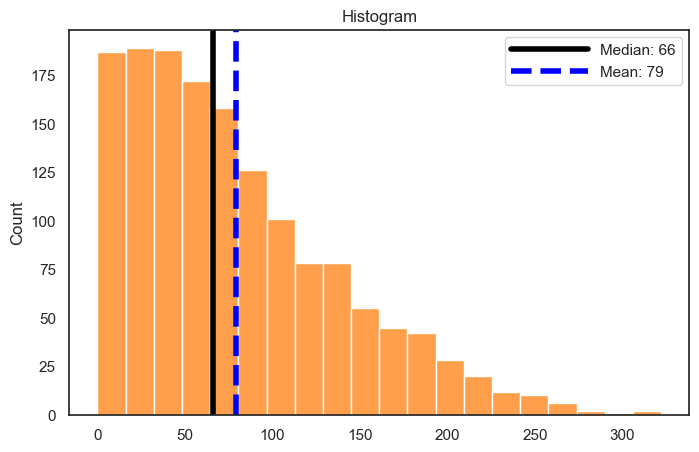

In [362]:
skew_demo = np.round(skewnorm.rvs(180, size=1500, random_state=68410237)*100, 0).astype(int)

skew_md = np.median(skew_demo)
skew_mn = np.mean(skew_demo)

sns.set_theme(style="white", palette=None)

fig, ax = plt.subplots(figsize=(8,5))

sns.histplot(skew_demo, bins=20,
             ax=ax, color='tab:orange')

ax.axvline(skew_md, color='black', linewidth=4,
           label='Median: {}'.format(int(skew_md)))
ax.axvline(skew_mn, color='blue', linestyle='dashed', linewidth=4,
           label='Mean: {}'.format(int(skew_mn)))

ax.legend(handlelength=5)

ax.set_title("Histogram")
plt.show()

sns.set()

In [363]:
skew_income = subset_customers['Income'].skew()
skew_clv = subset_customers['Customer Lifetime Value'].skew()

print(f"Income: skewness = {skew_income:.2f}")
print(f"Customer Lifetime Value: skewness = {skew_clv:.2f}")

Income: skewness = 0.28
Customer Lifetime Value: skewness = 3.07


According to the above : we agreed to impute missing values using the median

Median is chosen because it is less affected by outliers and both Income and Customer Lifetime Value are skewed.

In [364]:
subset_customers = subset_customers.fillna({
    'Income': subset_customers['Income'].median(),
    'Customer Lifetime Value': subset_customers['Customer Lifetime Value'].median()
})

In [365]:
subset_customers.isna().sum()

Loyalty#                   0
Province or State          0
City                       0
Latitude                   0
Longitude                  0
Gender                     0
Education                  0
Income                     0
Marital Status             0
LoyaltyStatus              0
EnrollmentDateOpening      0
CancellationDate           0
Customer Lifetime Value    0
EnrollmentType             0
dtype: int64

In [366]:
subset_customers.count()

Loyalty#                   16921
Province or State          16921
City                       16921
Latitude                   16921
Longitude                  16921
Gender                     16921
Education                  16921
Income                     16921
Marital Status             16921
LoyaltyStatus              16921
EnrollmentDateOpening      16921
CancellationDate           16921
Customer Lifetime Value    16921
EnrollmentType             16921
dtype: int64

In [367]:
#we are creating a subset which only have peaople who have cancelled so that we can see if there is any significant differences in the distrubution 

In [368]:
subset_non_active = subset_customers[subset_customers["CancellationDate"] != '1900-01-01'].copy()

In [369]:
subset_non_active.shape

(2308, 14)

In [370]:
subset_non_active.isna().sum()

Loyalty#                   0
Province or State          0
City                       0
Latitude                   0
Longitude                  0
Gender                     0
Education                  0
Income                     0
Marital Status             0
LoyaltyStatus              0
EnrollmentDateOpening      0
CancellationDate           0
Customer Lifetime Value    0
EnrollmentType             0
dtype: int64

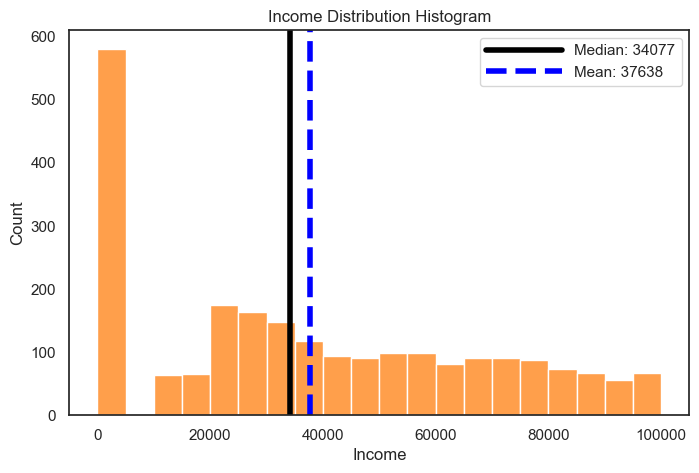

In [371]:
skew_demo = subset_non_active["Income"]

skew_demo = (
    skew_demo.astype(str)
             .str.replace(r"[,$]", "", regex=True)
             .replace(["", "nan", "None"], np.nan)
)
skew_demo = pd.to_numeric(skew_demo, errors="coerce").dropna()

skew_md = np.median(skew_demo)
skew_mn = np.mean(skew_demo)

sns.set_theme(style="white", palette=None)

fig, ax = plt.subplots(figsize=(8,5))

sns.histplot(skew_demo, bins=20,
             ax=ax, color='tab:orange')

ax.axvline(skew_md, color='black', linewidth=4,
           label='Median: {}'.format(int(skew_md)))
ax.axvline(skew_mn, color='blue', linestyle='dashed', linewidth=4,
           label='Mean: {}'.format(int(skew_mn)))

ax.legend(handlelength=5)

ax.set_title("Income Distribution Histogram")
plt.show()


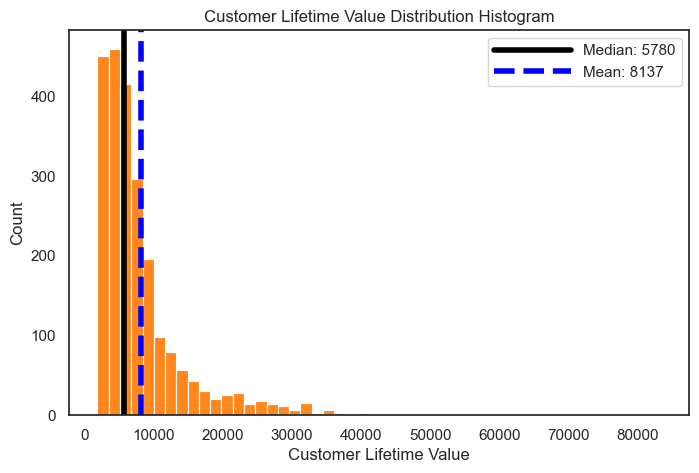

In [372]:
skew_demo = subset_non_active["Customer Lifetime Value"]

skew_demo = (
    skew_demo.astype(str)
             .str.replace(r"[,$]", "", regex=True)
             .replace(["", "nan", "None"], np.nan)
)
skew_demo = pd.to_numeric(skew_demo, errors="coerce").dropna()

skew_md = np.median(skew_demo)
skew_mn = np.mean(skew_demo)

sns.set_theme(style="white", palette=None)

fig, ax = plt.subplots(figsize=(8,5))

sns.histplot(skew_demo, bins=50,
             ax=ax, color='tab:orange')
sns.histplot(skew_demo, bins=50,
             ax=ax, color='tab:orange')

ax.axvline(skew_md, color='black', linewidth=4,
           label='Median: {}'.format(int(skew_md)))
ax.axvline(skew_mn, color='blue', linestyle='dashed', linewidth=4,
           label='Mean: {}'.format(int(skew_mn)))

ax.legend(handlelength=5)

ax.set_title("Customer Lifetime Value Distribution Histogram")
plt.show()

sns.set()


#### Handling outliers :

In [373]:
subset_customers.select_dtypes(include='number').columns

Index(['Loyalty#', 'Latitude', 'Longitude', 'Income',
       'Customer Lifetime Value'],
      dtype='object')

In [374]:
#creating boxplots for all numeric variables in the subset_customers dataset to visually inspect their distributions and detect possible outliers.

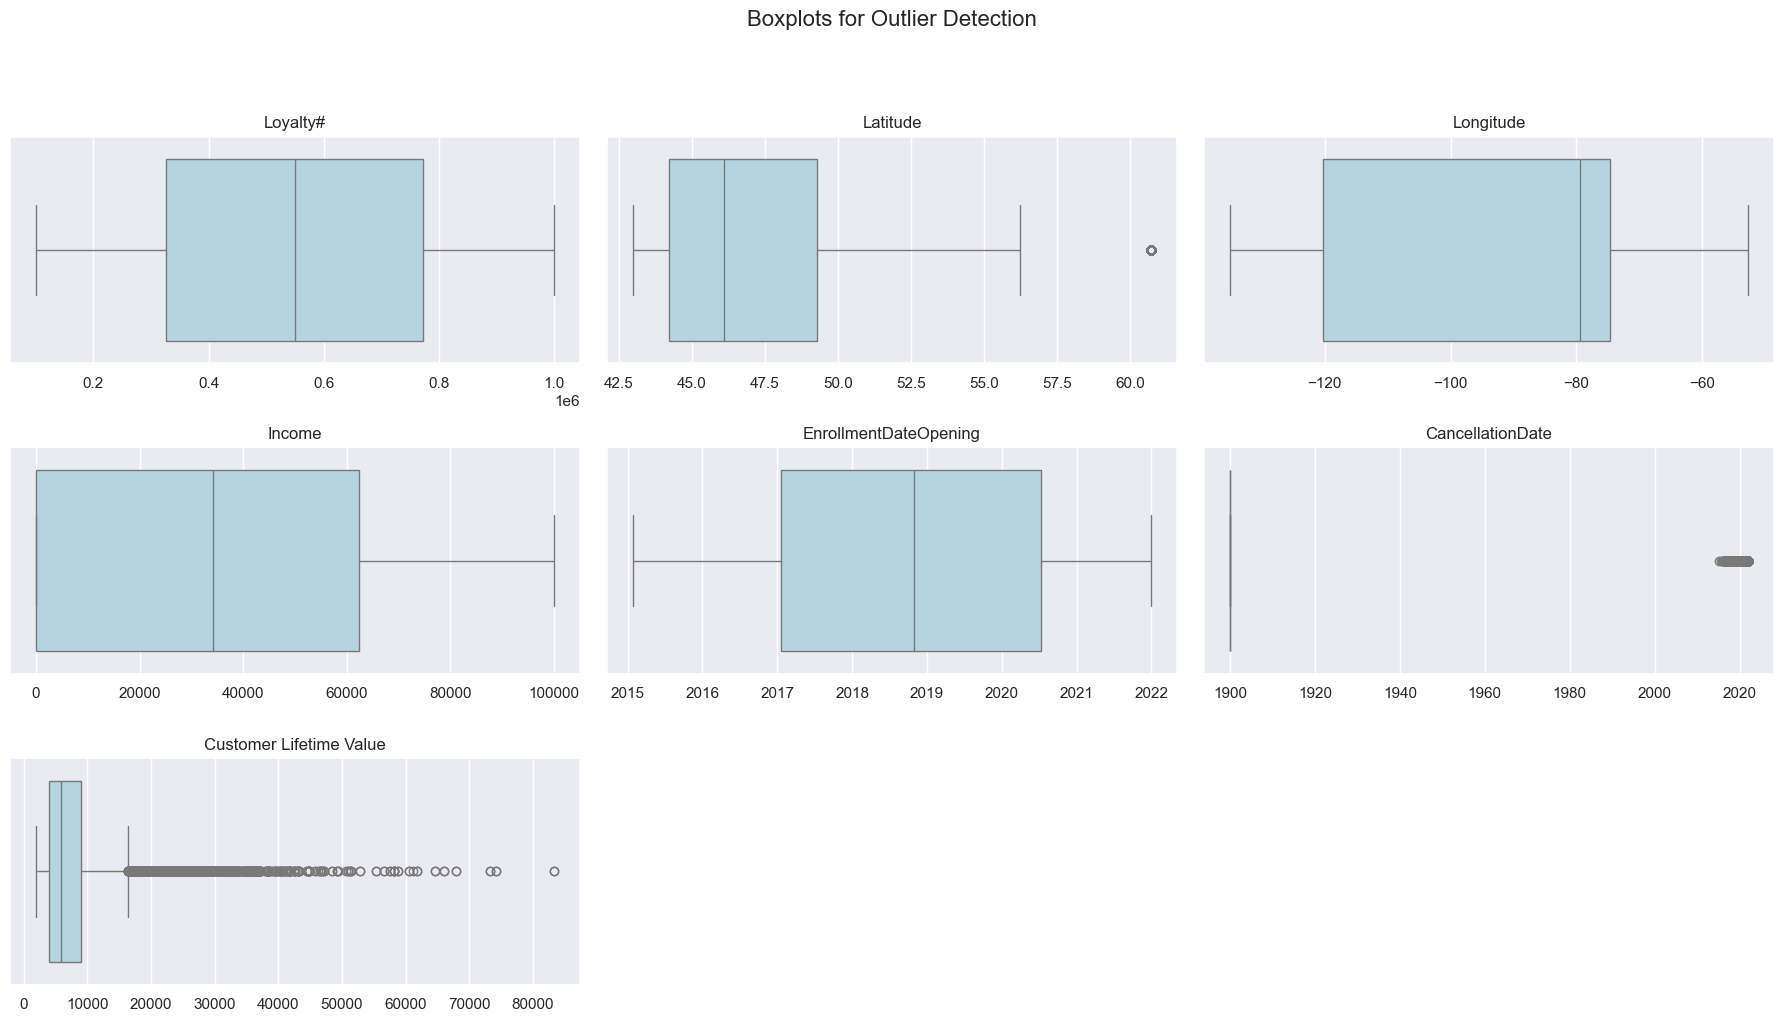

In [375]:
plt.figure(figsize=(18, 10))
plt.suptitle("Boxplots for Outlier Detection", fontsize=16, y=1.02)

for i, col in enumerate(Customers_metric_features , 1):
    plt.subplot(ceil(len(Customers_metric_features ) / 3), 3, i)
    sns.boxplot(x=subset_customers[col], color='lightblue')
    plt.title(col)
    plt.xlabel("")

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


- **Loyalty#**  
  Distribution appears fairly uniform with no extreme outliers.

- **Latitude & Longitude**  
  Mostly consistent values, but Longitude shows a slight outlier on the right side.

- **Income**  
  Wide range of values with some potential outliers on the higher end.  
  Indicates variability in customer income.

- **EnrollmentDateOpening**  
  Dates are concentrated between 2015 and 2021.  
  No significant outliers detected.

- **CancellationDate**  
  Most values are missing or concentrated around a single point (likely representing customers who have not canceled yet).

- **Customer Lifetime Value**  
  Highly skewed distribution with many extreme outliers on the higher end.  
  Suggests a few customers have very large lifetime values compared to the majority.


In [376]:
#We chose this manual filtering method because the boxplot of Customer Lifetime Value (CLV) showed clear extreme outliers.
#A manual threshold of CLV ≤ 60,000 was applied to remove unrealistic values while keeping most valid observations

In [377]:
filters_man = (
    (subset_customers['Customer Lifetime Value'] <= 60000) 
)

subset_cleaned_manual = subset_customers[filters_man]

print(
    'Percentage of data kept after removing outliers:',
    100 * np.round(subset_cleaned_manual.shape[0] / subset_customers.shape[0], 4)
)

Percentage of data kept after removing outliers: 99.9


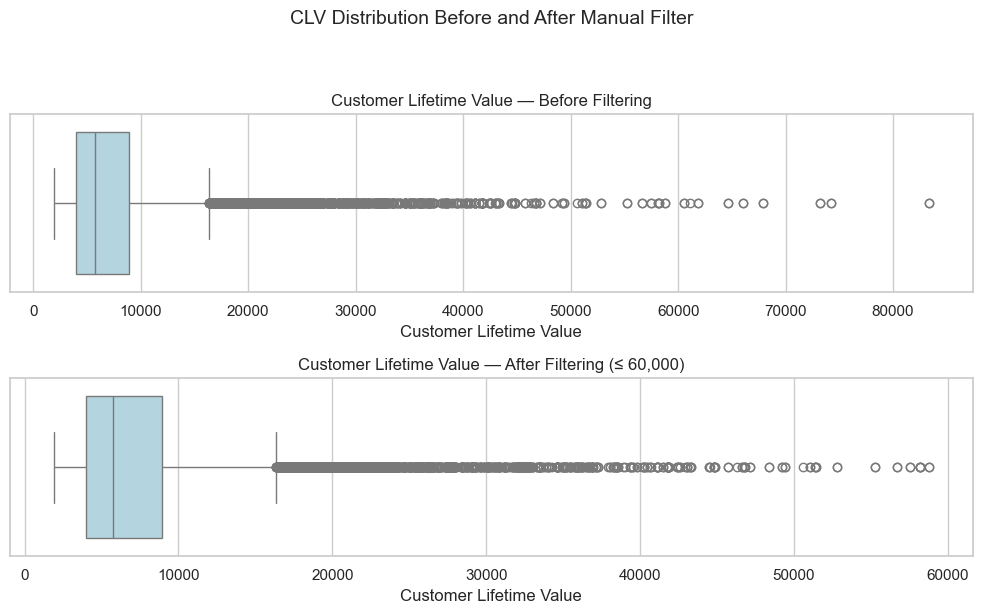

In [378]:
sns.set(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharey=True)

sns.boxplot(
    x=subset_customers["Customer Lifetime Value"],
    ax=axes[0],
    color='lightblue'
)
axes[0].set_title("Customer Lifetime Value — Before Filtering")

sns.boxplot(
    x=subset_cleaned_manual["Customer Lifetime Value"],
    ax=axes[1],
    color='lightblue'
)
axes[1].set_title("Customer Lifetime Value — After Filtering (≤ 60,000)")

plt.suptitle("CLV Distribution Before and After Manual Filter", fontsize=14, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()



In [379]:
#now we are checking the outliers in the flights dataset:

In [380]:
flights.select_dtypes(include='number').columns


Index(['Loyalty#', 'Year', 'Month', 'NumFlights', 'NumFlightsWithCompanions',
       'DistanceKM', 'PointsAccumulated', 'PointsRedeemed',
       'DollarCostPointsRedeemed'],
      dtype='object')

In [381]:
#creating boxplots for all numeric variables in the Flights dataset to visually inspect their distributions and detect possible outliers.

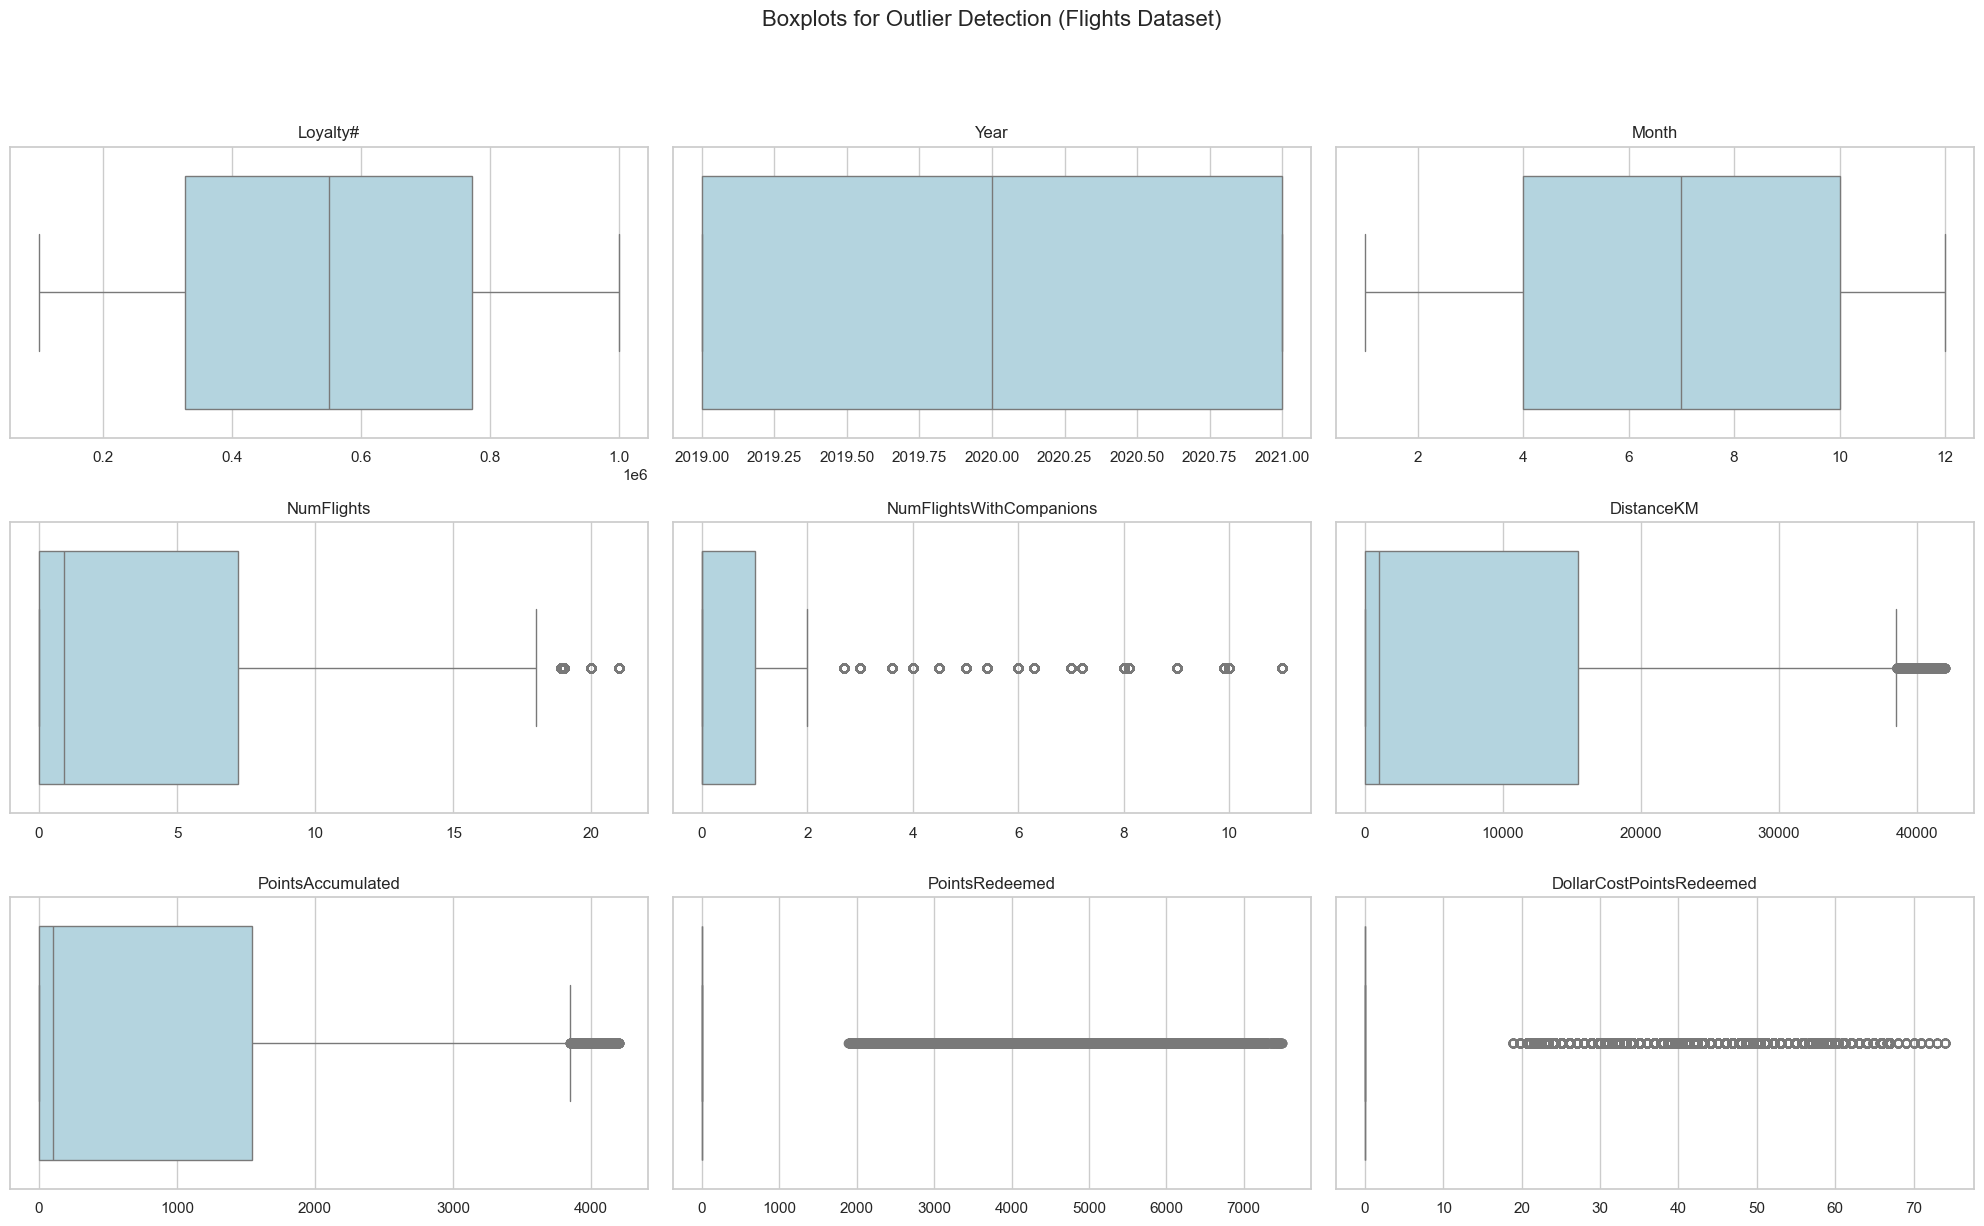

In [382]:
num_cols = ['Loyalty#', 'Year', 'Month', 'NumFlights', 'NumFlightsWithCompanions',
            'DistanceKM', 'PointsAccumulated', 'PointsRedeemed', 'DollarCostPointsRedeemed']

plt.figure(figsize=(20, 12))
plt.suptitle("Boxplots for Outlier Detection (Flights Dataset)", fontsize=16, y=1.02)

for i, col in enumerate(num_cols, 1):
    plt.subplot(ceil(len(num_cols) / 3), 3, i)
    sns.boxplot(x=flights[col], color='lightblue')
    plt.title(col)
    plt.xlabel("")

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


- **Loyalty#**  
  Distribution appears balanced with no significant outliers.

- **Year**  
  Values are concentrated between 2019 and 2021, as expected.  
  No major outliers detected.

- **Month**  
  Spread across 1–12 months with a uniform distribution.  
  No noticeable outliers.

- **NumFlights**  
  Most customers have fewer than 10 flights, but there are a few outliers above 15–20 flights.

- **NumFlightsWithCompanions**  
  Highly skewed with many zeros and several outliers above 5 flights with companions.

- **DistanceKM**  
  Majority of values are below 20,000 km, but there are extreme outliers reaching up to 40,000 km.

- **PointsAccumulated**  
  Most values are concentrated at lower ranges, but there are outliers above 4,000 points.

- **PointsRedeemed**  
  Distribution is skewed with several outliers above 7,000 points.

- **DollarCostPointsRedeemed**  
  Mostly concentrated at lower values, but there are many outliers above 50 units.


In [383]:
#The plots show that variables such as Number of Flights, DistanceKM, and Points Accumulated have several extreme values, while others like Year and Month appear well distributed.

In [384]:
perc_above_8 = (
    (flights["NumFlightsWithCompanions"] > 8).sum() / len(flights)
) * 100

print(f"Percentage of records with NumFlightsWithCompanions > 8: {perc_above_8:.2f}%")

Percentage of records with NumFlightsWithCompanions > 8: 1.08%


In [385]:
flights.count()

Loyalty#                    605533
Year                        605533
Month                       605533
YearMonthDate               605533
NumFlights                  605533
NumFlightsWithCompanions    605533
DistanceKM                  605533
PointsAccumulated           605533
PointsRedeemed              605533
DollarCostPointsRedeemed    605533
dtype: int64

In [386]:
#Apply IQR method to detect and keep reasonable values

In [387]:
df_original = flights

col = "NumFlightsWithCompanions"
s = df_original[col].dropna()

q1, q3 = s.quantile([0.25, 0.75])
iqr = q3 - q1
lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
mask_iqr = df_original[col].between(lo, hi, inclusive="both")

mask_manual = df_original[col] <= 8

keep_mask = mask_iqr | mask_manual
df_out = df_original[keep_mask]

print(
    "Percentage of data kept after filtering:",
    np.round(df_out.shape[0] / df_original.shape[0] * 100, 2), "%"
)

Percentage of data kept after filtering: 98.92 %


In [388]:
flights.count()

Loyalty#                    605533
Year                        605533
Month                       605533
YearMonthDate               605533
NumFlights                  605533
NumFlightsWithCompanions    605533
DistanceKM                  605533
PointsAccumulated           605533
PointsRedeemed              605533
DollarCostPointsRedeemed    605533
dtype: int64

In [389]:
# Use IQR to filter NumFlights

In [390]:

df = flights
metric_features = ["NumFlights"]

# Compute the IQR
q1 = df[metric_features].quantile(.25)

# Calculate Q3
q3 = df[metric_features].quantile(.75)

# Calculate IQR
iqr = (q3 - q1)

# Compute upper and lower limits
lower_lim = q1 - (1.5 * iqr)
upper_lim = q3 + (1.5 * iqr)

filters_iqr = []
for metric in metric_features:
    llim = lower_lim[metric]
    ulim = upper_lim[metric]
    filters_iqr.append(df[metric].between(llim, ulim, inclusive='neither'))

filters_iqr_all = pd.Series(np.all(filters_iqr, 0), index=df.index)

# Apply filter
df_iqr_clean = df[filters_iqr_all]

print('Percentage of data kept after IQR filtering:',
      100 * np.round(df_iqr_clean.shape[0] / df.shape[0], 4))


Percentage of data kept after IQR filtering: 98.86


In [391]:
flights.count()

Loyalty#                    605533
Year                        605533
Month                       605533
YearMonthDate               605533
NumFlights                  605533
NumFlightsWithCompanions    605533
DistanceKM                  605533
PointsAccumulated           605533
PointsRedeemed              605533
DollarCostPointsRedeemed    605533
dtype: int64

# 3.Deep Analysis and Feature Engineering

In [392]:
#This visualization identifies how many unique customers traveled from each city

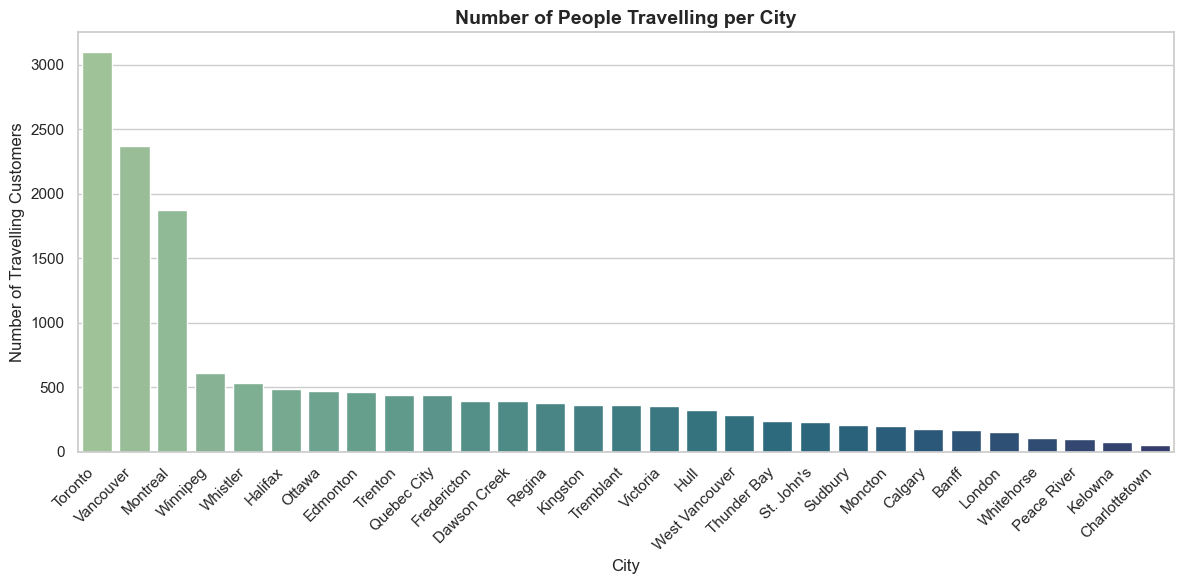

In [393]:

flown_customers = flights[flights["DistanceKM"] > 0]["Loyalty#"].unique()

travelling_customers = subset_customers[subset_customers["Loyalty#"].isin(flown_customers)]

travellers_per_city = (
    travelling_customers.groupby("City")["Loyalty#"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name="NumTravellers")
)

plt.figure(figsize=(12,6))
sns.barplot(
    data=travellers_per_city,
    x="City", y="NumTravellers",
    palette="crest"
)

plt.title("Number of People Travelling per City", fontsize=14, weight="bold")
plt.xlabel("City")
plt.ylabel("Number of Travelling Customers")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


- Toronto has the largest number of traveling customers, followed by Vancouver and Montreal.
- The distribution is highly skewed: a few major cities account for most travelers.
- This insight suggests that marketing or loyalty strategies could focus on these high-volume cities.


#### New Feature (HasFlown):

In [394]:
#Here in order to evaluate customer travel activity by ensuring flight distance data is accurate and consistent,
#identifying how many flights represent real travel versus inactivity.

In [395]:
flights["DistanceKM"] = pd.to_numeric(flights["DistanceKM"], errors="coerce")
print(flights["DistanceKM"].dtype)
print(flights["DistanceKM"].describe())

float64
count    605533.000000
mean       7977.403603
std       10270.215544
min           0.000000
25%           0.000000
50%         993.600000
75%       15408.900000
max       42040.000000
Name: DistanceKM, dtype: float64


In [396]:
# Count and percentage of zeros in DistanceKM
zero_count = (flights["DistanceKM"] == 0).sum()
zero_pct = (flights["DistanceKM"] == 0).mean() * 100

print(f"Number of zeros in DistanceKM: {zero_count}")
print(f"Percentage of zeros: {zero_pct:.2f}%")


Number of zeros in DistanceKM: 295720
Percentage of zeros: 48.84%


Nearly half of all flights record (48.84%) show a distance of 0 km, meaning many customers had months without any travel activity.

In [397]:
# creating new feature to indicate whether a flight record represents actual travel activity:

In [398]:
flights["HasFlown"] = flights["DistanceKM"].notna().astype(int)

In [399]:
#Created a box plot to visualize the DistanceKM for these active customer per year/month
# HasFlown = 1 if DistanceKM > 0 (real travel)

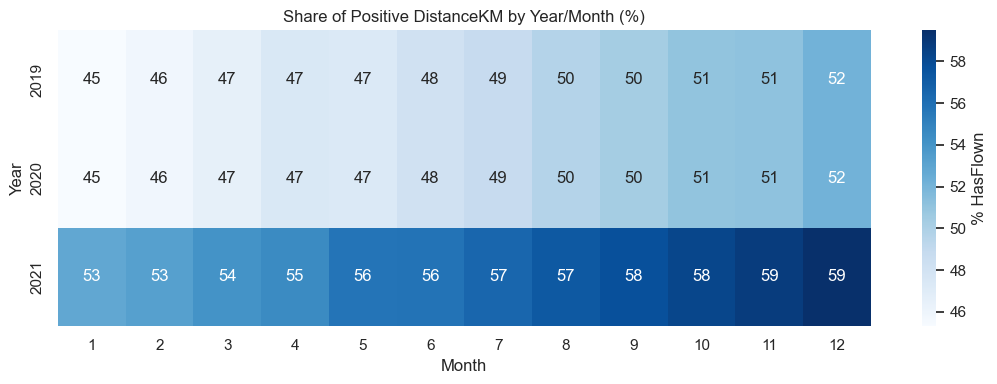

In [400]:
has_flown_rate = (flights.assign(HasFlown = flights["DistanceKM"].gt(0).astype(int))
                  .groupby(["Year","Month"])["HasFlown"]
                  .mean().unstack("Month"))

plt.figure(figsize=(11,4))
ax = sns.heatmap(100 * has_flown_rate, cmap="Blues", annot=True, fmt=".0f", cbar_kws={"label":"% HasFlown"})
ax.set_title("Share of Positive DistanceKM by Year/Month (%)")
ax.set_xlabel("Month")
ax.set_ylabel("Year")
plt.tight_layout()
plt.show()


- **2019 and 2020:**  
  Fairly stable, around **45–52%** across months.  
  Indicates that roughly half of the records in those years represent actual flights.

- **2021:**  
  Noticeable increase: **53–59%** across months.  
  Suggests higher engagement or better data completeness in 2021 compared to previous years.

- **Seasonality:**  
  Slight upward trend toward the end of each year (**Nov–Dec**), but overall variation is small.


In [401]:
#Distribution of real distances (non‑zero only)
# Only positive distances to study actual travel

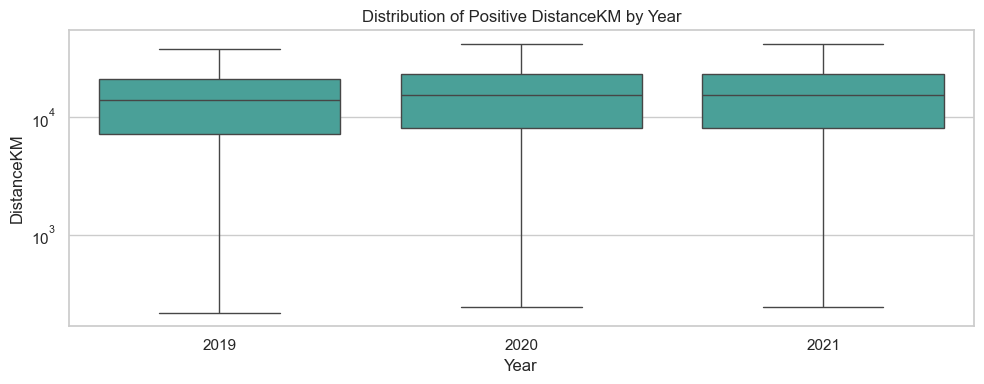

In [402]:

pos = flights[flights["DistanceKM"] > 0].copy()

plt.figure(figsize=(10,4))
ax = sns.boxplot(data=pos, x="Year", y="DistanceKM", color="#3CAEA3")
ax.set_title("Distribution of Positive DistanceKM by Year")
ax.set_xlabel("Year")
ax.set_ylabel("DistanceKM")
ax.set_yscale("log")   # long-tail friendly
plt.tight_layout()
plt.show()


In [403]:
flights.isna().sum()

Loyalty#                    0
Year                        0
Month                       0
YearMonthDate               0
NumFlights                  0
NumFlightsWithCompanions    0
DistanceKM                  0
PointsAccumulated           0
PointsRedeemed              0
DollarCostPointsRedeemed    0
HasFlown                    0
dtype: int64

#### New Feature (HasRedeemedPoints) :

In [404]:
flights.count()

Loyalty#                    605533
Year                        605533
Month                       605533
YearMonthDate               605533
NumFlights                  605533
NumFlightsWithCompanions    605533
DistanceKM                  605533
PointsAccumulated           605533
PointsRedeemed              605533
DollarCostPointsRedeemed    605533
HasFlown                    605533
dtype: int64

In [405]:
zero_pct = (flights["PointsRedeemed"] == 0).mean() * 100
print(f"Percentage of customers with 0 points redeemed: {zero_pct:.2f}%")


Percentage of customers with 0 points redeemed: 94.16%


In [406]:
flights["HasRedeemedPoints"] = (flights["PointsRedeemed"] > 0).astype(int)

flights["HasRedeemedPoints"].value_counts(normalize=True) * 100

HasRedeemedPoints
0    94.155067
1     5.844933
Name: proportion, dtype: float64

In [407]:
zero_pct = (flights["DollarCostPointsRedeemed"] == 0).mean() * 100
print(f"Percentage of customers with 0 dollar cost points redeemed: {zero_pct:.2f}%")


Percentage of customers with 0 dollar cost points redeemed: 94.16%


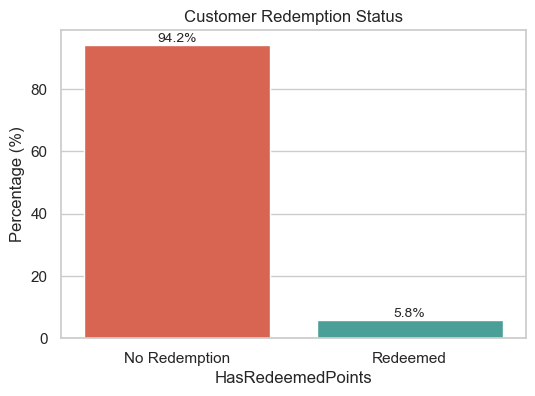

In [408]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(6,4))
ax = sns.barplot(
    x=flights["HasRedeemedPoints"].value_counts().index,
    y=flights["HasRedeemedPoints"].value_counts(normalize=True)*100,
    palette=["#ED553B","#3CAEA3"]
)
ax.set_xticklabels(["No Redemption","Redeemed"])
ax.set_ylabel("Percentage (%)")
ax.set_title("Customer Redemption Status")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", (p.get_x()+p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=10)
plt.show()


- About **94% of customers have not redeemed any points**, and only ~6% have redeemed at least once.  
- Similarly, **94% have not redeemed dollar-cost points**.  
- This indicates that the redemption feature is rarely used, suggesting low engagement with the loyalty program and an opportunity to improve awareness or incentives for redemption.


In [409]:
flights.isna().sum()

Loyalty#                    0
Year                        0
Month                       0
YearMonthDate               0
NumFlights                  0
NumFlightsWithCompanions    0
DistanceKM                  0
PointsAccumulated           0
PointsRedeemed              0
DollarCostPointsRedeemed    0
HasFlown                    0
HasRedeemedPoints           0
dtype: int64

#### New Feature (RedeemRate) :

In [410]:
#RedeemRate adds depth to behavioral analysis by showing redemption intensity, while HasRedeemedPoints remains useful for simple flags and interpretability.

In [411]:
flights['RedeemRate'] = (
    flights['PointsRedeemed'].fillna(0) /
    flights['PointsAccumulated'].replace({0: np.nan})  
).replace([np.inf, -np.inf], np.nan) \
 .fillna(0) \
 .clip(0, 1)

In [412]:
flights.isna().sum()

Loyalty#                    0
Year                        0
Month                       0
YearMonthDate               0
NumFlights                  0
NumFlightsWithCompanions    0
DistanceKM                  0
PointsAccumulated           0
PointsRedeemed              0
DollarCostPointsRedeemed    0
HasFlown                    0
HasRedeemedPoints           0
RedeemRate                  0
dtype: int64

#### New Feature (AverageDistancePerFlight) :

In [413]:
# Create a new feature (AverageDistancePerFlight) representing the average distance traveled per flight by each customer. 
# This helps identify customers who take short vs. long trips.

In [414]:

flights['NumFlights']  = pd.to_numeric(flights['NumFlights'],  errors='coerce')
flights['DistanceKM']  = pd.to_numeric(flights['DistanceKM'], errors='coerce')

flights['avg_distance_per_flight'] = flights['DistanceKM'].div(
    flights['NumFlights'].replace(0, np.nan)
).fillna(0)


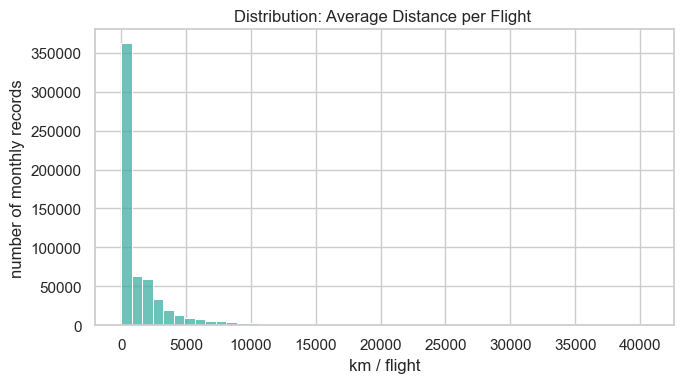

In [415]:


sns.set_theme(style="whitegrid")
plt.figure(figsize=(7,4))
sns.histplot(flights['avg_distance_per_flight'], bins=50, color="#3CAEA3")
plt.title("Distribution: Average Distance per Flight ")
plt.xlabel("km / flight"); plt.ylabel("number of monthly records")
plt.tight_layout(); plt.show()



- Each bar shows how many monthly records fall into a specific range of **Average Distance per Flight** (km per flight).
- The very tall bar near zero indicates that **most months had short flights**, typically less than **1,000 km per flight**.
- Bars that appear far to the right, even if small, represent **rare months with very long flights** (long-haul journeys).


In [416]:
flights.isna().sum()

Loyalty#                    0
Year                        0
Month                       0
YearMonthDate               0
NumFlights                  0
NumFlightsWithCompanions    0
DistanceKM                  0
PointsAccumulated           0
PointsRedeemed              0
DollarCostPointsRedeemed    0
HasFlown                    0
HasRedeemedPoints           0
RedeemRate                  0
avg_distance_per_flight     0
dtype: int64

#### New Feature (companion_ratio) :

In [417]:
# Create a new feature (companion_ratio) representing the proportion of flights
# taken with companions compared to the total number of flights.
# This feature helps identify customers who usually travel alone or with others.

In [418]:
flights['companion_ratio'] = (flights['NumFlightsWithCompanions'] / flights['NumFlights']).clip(0,1).fillna(0)

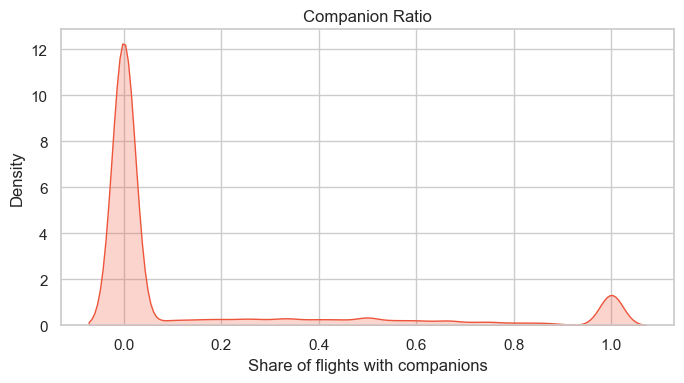

In [419]:
plt.figure(figsize=(7,4))
sns.kdeplot(data=flights, x='companion_ratio', fill=True, color="#ED553B", bw_adjust=1.1)
plt.title("Companion Ratio")
plt.xlabel("Share of flights with companions"); plt.ylabel("Density")
plt.tight_layout(); plt.show()



- The plot shows the **distribution of Companion Ratio**, which represents the share of flights taken with companions in a given month.
- Most observations cluster near **0**, meaning most months had few or no flights with companions (solo travel).
- A smaller peak near **1** indicates some months where all flights were with companions (group or family travel).
- This feature helps us understand **travel style** (solo vs. accompanied), which is useful for behavioral segmentation.


In [420]:
flights.isna().sum()

Loyalty#                    0
Year                        0
Month                       0
YearMonthDate               0
NumFlights                  0
NumFlightsWithCompanions    0
DistanceKM                  0
PointsAccumulated           0
PointsRedeemed              0
DollarCostPointsRedeemed    0
HasFlown                    0
HasRedeemedPoints           0
RedeemRate                  0
avg_distance_per_flight     0
companion_ratio             0
dtype: int64

#### New Feature (income_category) :

In [421]:
subset_customers['income_category'] = pd.cut(subset_customers['Income'], bins=[-1,0, 30000, 60000, 100000], labels=['No Income','Low', 'Medium', 'High'])

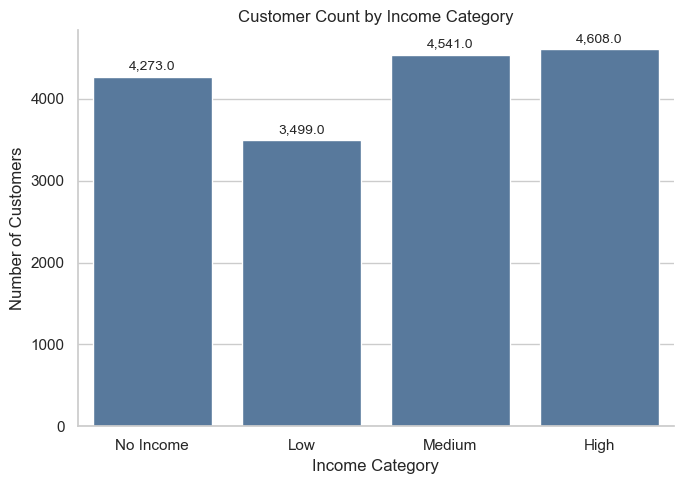

In [422]:
order = ['No Income','Low', 'Medium', 'High']

plt.figure(figsize=(7, 5))
ax = sns.countplot(
    data=subset_customers,
    x='income_category',
    order=order,
    color='#4C78A8'
)
ax.set_title('Customer Count by Income Category')
ax.set_xlabel('Income Category')
ax.set_ylabel('Number of Customers')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:,}', (p.get_x() + p.get_width()/2, height),
                ha='center', va='bottom', fontsize=10, xytext=(0, 3), textcoords='offset points')

sns.despine()
plt.tight_layout()
plt.show()


- **The majority of customers fall into the Medium and High income categories**, indicating that the customer base tends to have moderate to high purchasing power.
- **The Low income group is significantly smaller**, which could influence marketing strategies, product pricing, and targeted promotions.
- The **No Income group being large** might represent customers with missing income data or those genuinely without income (students, dependents).

In [423]:
subset_customers.isna().sum()

Loyalty#                   0
Province or State          0
City                       0
Latitude                   0
Longitude                  0
Gender                     0
Education                  0
Income                     0
Marital Status             0
LoyaltyStatus              0
EnrollmentDateOpening      0
CancellationDate           0
Customer Lifetime Value    0
EnrollmentType             0
income_category            0
dtype: int64

#### Merging the two datasets in one dataset :

In [424]:
merged = flights.merge(subset_customers, on="Loyalty#", how="right")
merged.head()

,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed,...,Gender,Education,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType,income_category
0,480934,2020.0,5.0,2020-05-01,13.0,4.0,25010.0,2501.0,0.0,0.0,...,female,Bachelor,70146.0,Married,Star,2019-02-15,1900-01-01,3839.14,Standard,High
1,480934,2020.0,4.0,2020-04-01,0.0,0.0,5095.0,509.0,0.0,0.0,...,female,Bachelor,70146.0,Married,Star,2019-02-15,1900-01-01,3839.14,Standard,High
2,480934,2020.0,2.0,2020-02-01,3.0,0.0,24271.0,2427.0,0.0,0.0,...,female,Bachelor,70146.0,Married,Star,2019-02-15,1900-01-01,3839.14,Standard,High
3,480934,2020.0,3.0,2020-03-01,0.0,0.0,0.0,0.0,0.0,0.0,...,female,Bachelor,70146.0,Married,Star,2019-02-15,1900-01-01,3839.14,Standard,High
4,480934,2020.0,1.0,2020-01-01,0.0,0.0,0.0,0.0,0.0,0.0,...,female,Bachelor,70146.0,Married,Star,2019-02-15,1900-01-01,3839.14,Standard,High


In [425]:
merged.columns

Index(['Loyalty#', 'Year', 'Month', 'YearMonthDate', 'NumFlights',
       'NumFlightsWithCompanions', 'DistanceKM', 'PointsAccumulated',
       'PointsRedeemed', 'DollarCostPointsRedeemed', 'HasFlown',
       'HasRedeemedPoints', 'RedeemRate', 'avg_distance_per_flight',
       'companion_ratio', 'Province or State', 'City', 'Latitude', 'Longitude',
       'Gender', 'Education', 'Income', 'Marital Status', 'LoyaltyStatus',
       'EnrollmentDateOpening', 'CancellationDate', 'Customer Lifetime Value',
       'EnrollmentType', 'income_category'],
      dtype='object')

In [426]:
merged.dtypes

Loyalty#                             int64
Year                               float64
Month                              float64
YearMonthDate               datetime64[ns]
NumFlights                         float64
NumFlightsWithCompanions           float64
DistanceKM                         float64
PointsAccumulated                  float64
PointsRedeemed                     float64
DollarCostPointsRedeemed           float64
HasFlown                           float64
HasRedeemedPoints                  float64
RedeemRate                         float64
avg_distance_per_flight            float64
companion_ratio                    float64
Province or State                   object
City                                object
Latitude                           float64
Longitude                          float64
Gender                              object
Education                           object
Income                             float64
Marital Status                      object
LoyaltyStat

# 4. Feature Selection :

In [427]:
categorical_cols = merged.select_dtypes(exclude=["number"]).columns.tolist()
print("Categorical columns:", categorical_cols)


numerical_cols = merged.select_dtypes(include=["number"]).columns.tolist()
print("Numerical columns:", numerical_cols)


Categorical columns: ['YearMonthDate', 'Province or State', 'City', 'Gender', 'Education', 'Marital Status', 'LoyaltyStatus', 'EnrollmentDateOpening', 'CancellationDate', 'EnrollmentType', 'income_category']
Numerical columns: ['Loyalty#', 'Year', 'Month', 'NumFlights', 'NumFlightsWithCompanions', 'DistanceKM', 'PointsAccumulated', 'PointsRedeemed', 'DollarCostPointsRedeemed', 'HasFlown', 'HasRedeemedPoints', 'RedeemRate', 'avg_distance_per_flight', 'companion_ratio', 'Latitude', 'Longitude', 'Income', 'Customer Lifetime Value']


In [428]:
categorical_Features= [
    'Province or State', 'City', 'Gender', 'Education',
    'Marital Status', 'LoyaltyStatus', 'EnrollmentType', 'income_category'
]

datetime_Features = ['YearMonthDate', 'EnrollmentDateOpening', 'CancellationDate']

metric_Features = ['Year' ,
    'Month',
    'NumFlights',
    'NumFlightsWithCompanions',
    'DistanceKM',
    'PointsAccumulated',
    'PointsRedeemed',
    'DollarCostPointsRedeemed',
    'HasFlown',
    'HasRedeemedPoints',
    'RedeemRate',
    'avg_distance_per_flight',
    'companion_ratio',
   'Longitude', 'Latitude',
    'Income',
    'Customer Lifetime Value',
   ]

print("Numerical columns:", metric_Features)
print("Categorical columns:", categorical_Features)
print("Datetime/Other columns:", datetime_Features)


Numerical columns: ['Year', 'Month', 'NumFlights', 'NumFlightsWithCompanions', 'DistanceKM', 'PointsAccumulated', 'PointsRedeemed', 'DollarCostPointsRedeemed', 'HasFlown', 'HasRedeemedPoints', 'RedeemRate', 'avg_distance_per_flight', 'companion_ratio', 'Longitude', 'Latitude', 'Income', 'Customer Lifetime Value']
Categorical columns: ['Province or State', 'City', 'Gender', 'Education', 'Marital Status', 'LoyaltyStatus', 'EnrollmentType', 'income_category']
Datetime/Other columns: ['YearMonthDate', 'EnrollmentDateOpening', 'CancellationDate']


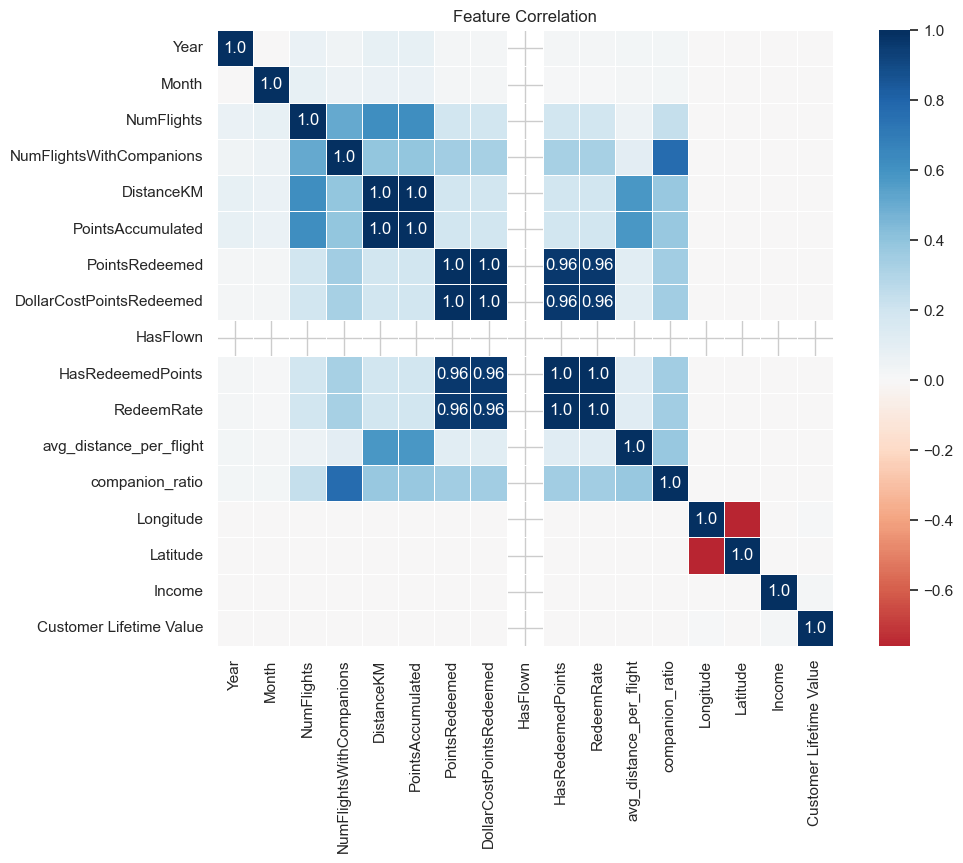

In [429]:
plt.figure(figsize=(12,8))
corr = merged[metric_Features].corr()
corr = corr.round(2)

sns.heatmap(
    corr,
    center = 0,
    cmap='RdBu',
    annot=np.where(np.absolute(corr) >= 0.9, corr.values, np.full(corr.values.shape, "")),
    fmt='s',
    square=True,
    linewidths=.5,
)
plt.title("Feature Correlation")
plt.show()

- Strong Positive Correlations (Green, near 1.0):
**NumFlights, NumFlightsWithCompanions, DistanceKM, PointsAccumulated, PointsRedeemed, DollarCostPointsRedeemed, HasFlown, HasRedeemedPoints, and total_flights** are almost perfectly correlated.
- **Customer Lifetime Value (CLV)** Positively associated with the loyalty_duration_days.
- **avg_distance_per_flight** correlates with **DistanceKM** but less with flight count.
- companion_ratio aligns with NumFlightsWithCompanions but is relatively independent from overall activity.
- **Latitude and Longitude** show strong negative correlation (geographic artifact).
- **Year and Month** as raw numbers do not explain seasonality well.

In [430]:
#According to the above insights , we decided to drop the following :

In [431]:
merged = merged.drop(columns=[
    'PointsRedeemed',
    'DollarCostPointsRedeemed',                 
    'HasRedeemedPoints', 
    'EnrollmentDateOpening', 'CancellationDate',
    'NumFlightsWithCompanions',
    'Year', 'Month', 'Latitude', 'Longitude',
    'Loyalty#', 'Province or State', 'City','income_category','YearMonthDate','HasFlown'
], errors='ignore')


In [432]:
merged.columns

Index(['NumFlights', 'DistanceKM', 'PointsAccumulated', 'RedeemRate',
       'avg_distance_per_flight', 'companion_ratio', 'Gender', 'Education',
       'Income', 'Marital Status', 'LoyaltyStatus', 'Customer Lifetime Value',
       'EnrollmentType'],
      dtype='object')

In [433]:
num_cols = merged.select_dtypes(include=['number']).columns.tolist()

cat_cols = merged.select_dtypes(include=['object', 'category']).columns.tolist()

bool_cols = merged.select_dtypes(include=['bool']).columns.tolist()
datetime_cols = merged.select_dtypes(include=['datetime']).columns.tolist()

print("Numerical:", num_cols)
print("Categorical:", cat_cols)
print("Boolean:", bool_cols)
print("Datetime:", datetime_cols)


Numerical: ['NumFlights', 'DistanceKM', 'PointsAccumulated', 'RedeemRate', 'avg_distance_per_flight', 'companion_ratio', 'Income', 'Customer Lifetime Value']
Categorical: ['Gender', 'Education', 'Marital Status', 'LoyaltyStatus', 'EnrollmentType']
Boolean: []
Datetime: []


#### ENCODING :

In [434]:
cat_cols = merged.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical:", cat_cols)


Categorical: ['Gender', 'Education', 'Marital Status', 'LoyaltyStatus', 'EnrollmentType']


In [435]:
cat_cols = merged.select_dtypes(include=['object', 'category']).columns.unique().tolist()

merged[cat_cols] = merged[cat_cols].apply(lambda s: s.astype('category'))

categories_by_col = {
    col: merged[col].cat.categories.tolist()
    for col in cat_cols
}
for col, cats in categories_by_col.items():
    print(f"=== {col} ===")
    print(f"Number of categories: {len(cats)}")
    print(cats)
    print()


=== Gender ===
Number of categories: 2
['female', 'male']

=== Education ===
Number of categories: 5
['Bachelor', 'College', 'Doctor', 'High School or Below', 'Master']

=== Marital Status ===
Number of categories: 3
['Divorced', 'Married', 'Single']

=== LoyaltyStatus ===
Number of categories: 3
['Aurora', 'Nova', 'Star']

=== EnrollmentType ===
Number of categories: 2
['2021 Promotion', 'Standard']



In [436]:
# We apply Binary Encoding for categorical features with only two categories 
#For categorical features with more than two categories , we apply One-Hot Encoding

In [437]:
merged['Gender'] = (merged['Gender'] == 'male').astype(int)
merged['EnrollmentType'] = (merged['EnrollmentType'] == 'Standard').astype(int)

merged = pd.get_dummies(
    merged,
    columns=['Education', 'Marital Status', 'LoyaltyStatus'],
    drop_first=True  
)

print("Shape after encoding:", merged.shape)
merged.head()

Shape after encoding: (614472, 18)


,NumFlights,DistanceKM,PointsAccumulated,RedeemRate,avg_distance_per_flight,companion_ratio,Gender,Income,Customer Lifetime Value,EnrollmentType,Education_College,Education_Doctor,Education_High School or Below,Education_Master,Marital Status_Married,Marital Status_Single,LoyaltyStatus_Nova,LoyaltyStatus_Star
0,13.0,25010.0,2501.0,0.0,1923.846154,0.307692,0,70146.0,3839.14,1,False,False,False,False,True,False,False,True
1,0.0,5095.0,509.0,0.0,0.000000,0.000000,0,70146.0,3839.14,1,False,False,False,False,True,False,False,True
2,3.0,24271.0,2427.0,0.0,8090.333333,0.000000,0,70146.0,3839.14,1,False,False,False,False,True,False,False,True
3,0.0,0.0,0.0,0.0,0.000000,0.000000,0,70146.0,3839.14,1,False,False,False,False,True,False,False,True
4,0.0,0.0,0.0,0.0,0.000000,0.000000,0,70146.0,3839.14,1,False,False,False,False,True,False,False,True


#### SCALING :

In [438]:
#Applying Standard Scaling : 

In [439]:
num_cols = merged.select_dtypes(include=['number']).columns.tolist()
print("Numerical columns:", num_cols)

Numerical columns: ['NumFlights', 'DistanceKM', 'PointsAccumulated', 'RedeemRate', 'avg_distance_per_flight', 'companion_ratio', 'Gender', 'Income', 'Customer Lifetime Value', 'EnrollmentType']


In [440]:
merged[num_cols].describe(include='all')
merged[num_cols].isna().sum()

NumFlights                 20
DistanceKM                 20
PointsAccumulated          20
RedeemRate                 20
avg_distance_per_flight    20
companion_ratio            20
Gender                      0
Income                      0
Customer Lifetime Value     0
EnrollmentType              0
dtype: int64

In [441]:
merged['NumFlights'] = merged['NumFlights'].fillna(merged['NumFlights'].median())
merged['DistanceKM'] = merged['DistanceKM'].fillna(merged['DistanceKM'].median())
merged['PointsAccumulated'] = merged['PointsAccumulated'].fillna(merged['PointsAccumulated'].median())
merged['RedeemRate'] = merged['RedeemRate'].fillna(merged['RedeemRate'].median())
merged['avg_distance_per_flight'] = merged['avg_distance_per_flight'].fillna(merged['avg_distance_per_flight'].median())
merged['companion_ratio'] = merged['companion_ratio'].fillna(merged['companion_ratio'].median())


In [442]:
merged.isna().sum()


NumFlights                        0
DistanceKM                        0
PointsAccumulated                 0
RedeemRate                        0
avg_distance_per_flight           0
companion_ratio                   0
Gender                            0
Income                            0
Customer Lifetime Value           0
EnrollmentType                    0
Education_College                 0
Education_Doctor                  0
Education_High School or Below    0
Education_Master                  0
Marital Status_Married            0
Marital Status_Single             0
LoyaltyStatus_Nova                0
LoyaltyStatus_Star                0
dtype: int64

In [443]:
scaler = StandardScaler()
merged[num_cols] = scaler.fit_transform(merged[num_cols])
merged[num_cols].head()

,NumFlights,DistanceKM,PointsAccumulated,RedeemRate,avg_distance_per_flight,companion_ratio,Gender,Income,Customer Lifetime Value,EnrollmentType
0,1.792346,1.658008,1.658360,-0.249111,0.052543,0.483020,-0.996809,1.065992,-0.604445,0.269005
1,-0.775724,-0.280943,-0.281311,-0.249111,-0.470075,-0.508304,-0.996809,1.065992,-0.604445,0.269005
2,-0.183092,1.586058,1.586304,-0.249111,1.727685,-0.508304,-0.996809,1.065992,-0.604445,0.269005
3,-0.775724,-0.776999,-0.776939,-0.249111,-0.470075,-0.508304,-0.996809,1.065992,-0.604445,0.269005
4,-0.775724,-0.776999,-0.776939,-0.249111,-0.470075,-0.508304,-0.996809,1.065992,-0.604445,0.269005


In [444]:
final_df = merged.copy()
final_df.head()

,NumFlights,DistanceKM,PointsAccumulated,RedeemRate,avg_distance_per_flight,companion_ratio,Gender,Income,Customer Lifetime Value,EnrollmentType,Education_College,Education_Doctor,Education_High School or Below,Education_Master,Marital Status_Married,Marital Status_Single,LoyaltyStatus_Nova,LoyaltyStatus_Star
0,1.792346,1.658008,1.658360,-0.249111,0.052543,0.483020,-0.996809,1.065992,-0.604445,0.269005,False,False,False,False,True,False,False,True
1,-0.775724,-0.280943,-0.281311,-0.249111,-0.470075,-0.508304,-0.996809,1.065992,-0.604445,0.269005,False,False,False,False,True,False,False,True
2,-0.183092,1.586058,1.586304,-0.249111,1.727685,-0.508304,-0.996809,1.065992,-0.604445,0.269005,False,False,False,False,True,False,False,True
3,-0.775724,-0.776999,-0.776939,-0.249111,-0.470075,-0.508304,-0.996809,1.065992,-0.604445,0.269005,False,False,False,False,True,False,False,True
4,-0.775724,-0.776999,-0.776939,-0.249111,-0.470075,-0.508304,-0.996809,1.065992,-0.604445,0.269005,False,False,False,False,True,False,False,True


# 5.Clustering Methods and Results

### Hierarchical clustering

In [445]:
cluster_features = ['NumFlights', 
                    'DistanceKM', 
                    'PointsAccumulated',
                    'RedeemRate',
                    'avg_distance_per_flight',
                    'companion_ratio', 
                    'Income',
                    'Customer Lifetime Value',
                    ] 
df_cluster = final_df[cluster_features]

In [446]:
final_df[cluster_features].shape

(614472, 8)

In [447]:
sample_n = 8000
df_sample = df_cluster.sample(sample_n, random_state=1)
print("Sample Shape:", df_sample.shape)

Sample Shape: (8000, 8)


In [448]:
n_clusters = 3  
hclust = AgglomerativeClustering(
    linkage='ward',
    metric='euclidean',
    n_clusters=n_clusters
)

labels = hclust.fit_predict(df_sample)


Cluster Means:

labels                          0         1         2
NumFlights               0.754760 -0.742582  0.820328
DistanceKM               0.801265 -0.757413  0.703251
PointsAccumulated        0.801221 -0.757365  0.703198
RedeemRate              -0.249111 -0.249111  4.013809
avg_distance_per_flight  0.503188 -0.454982  0.324897
companion_ratio          0.394388 -0.507003  1.280648
Income                   0.020763 -0.019006 -0.070635
Customer Lifetime Value -0.013267  0.043211 -0.054346


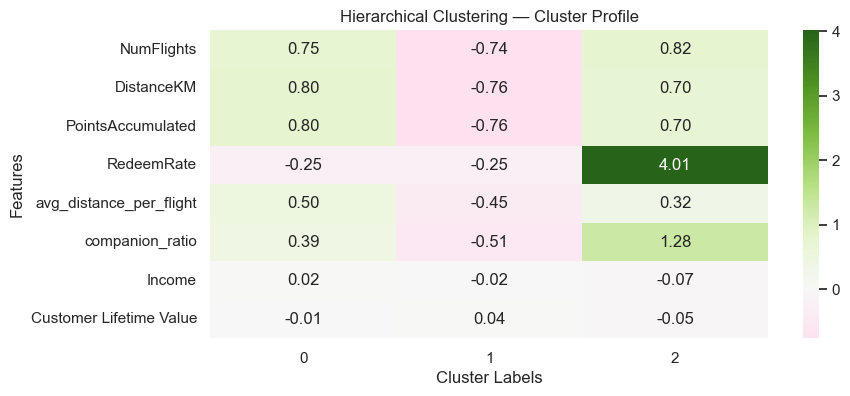

In [449]:
df_labeled = pd.concat(
    [df_sample.reset_index(drop=True),
     pd.Series(labels, name='labels')],
    axis=1
)

cluster_means = df_labeled.groupby('labels').mean().T
print("\nCluster Means:\n")
print(cluster_means)

plt.figure(figsize=(9,4))
sns.heatmap(cluster_means, annot=True, center=0, cmap="PiYG", fmt=".2f")
plt.title("Hierarchical Clustering — Cluster Profile")
plt.xlabel("Cluster Labels")
plt.ylabel("Features")
plt.show()


The values shown in the heatmap represent standardized cluster means.
Positive values indicate above-average behavior, negative values indicate
below-average behavior, and values close to zero represent typical or neutral
customer behavior. The obtained patterns are logically consistent: **Cluster 2**
contains highly active and loyalty-engaged travelers, **Cluster 0** represents
average users with moderate activity, and **Cluster 1** captures low-engagement
customers. Income and CLV remain near zero across clusters, suggesting these
features do not significantly differentiate user groups in this dataset.

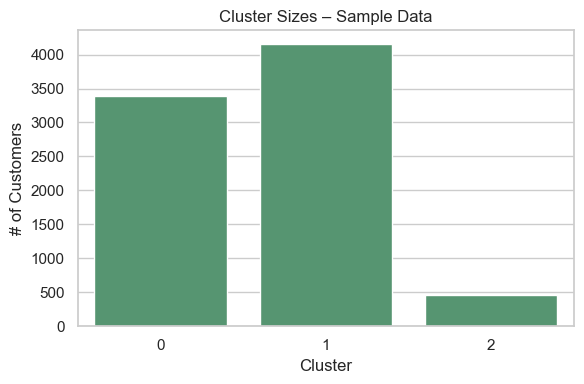

In [450]:
cluster_sizes = df_labeled['labels'].value_counts().sort_index()

plt.figure(figsize=(6, 4))
sns.barplot(x=cluster_sizes.index, y=cluster_sizes.values, color="#4c9f70")
plt.title("Cluster Sizes – Sample Data")
plt.xlabel("Cluster")
plt.ylabel("# of Customers")
plt.tight_layout()
plt.show()


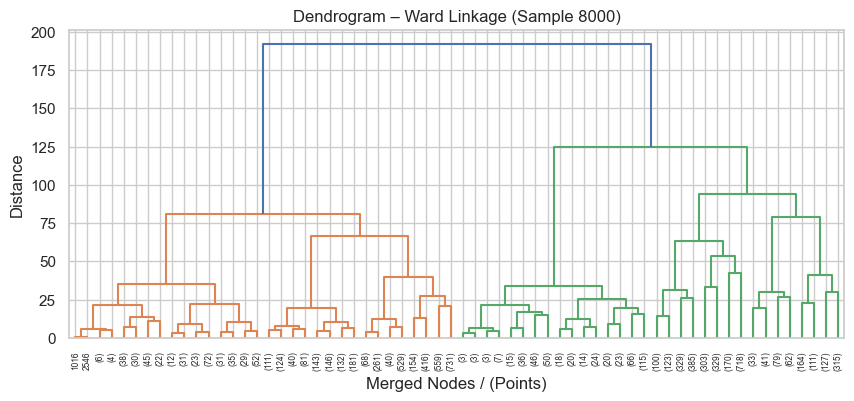

In [451]:
Z = linkage(df_sample, method='ward')

plt.figure(figsize=(10,4))
dendrogram(Z, truncate_mode="level", p=5)
plt.title("Dendrogram – Ward Linkage (Sample 8000)")
plt.xlabel("Merged Nodes / (Points)")
plt.ylabel("Distance")
plt.show()

#### K - Means Clustering :

We perform clustering using the numeric variables selected during the EDA phase. Education and loyalty status were numerically encoded and included in clustering; cluster-level averages should be interpreted as tendencies rather than exact category values.

In [452]:
final_df.columns

Index(['NumFlights', 'DistanceKM', 'PointsAccumulated', 'RedeemRate',
       'avg_distance_per_flight', 'companion_ratio', 'Gender', 'Income',
       'Customer Lifetime Value', 'EnrollmentType', 'Education_College',
       'Education_Doctor', 'Education_High School or Below',
       'Education_Master', 'Marital Status_Married', 'Marital Status_Single',
       'LoyaltyStatus_Nova', 'LoyaltyStatus_Star'],
      dtype='object')

In [470]:
cluster_features = [
    'NumFlights',
    'companion_ratio',
    'DistanceKM',
    'RedeemRate',
    'Income',
    'Customer Lifetime Value',
    'PointsAccumulated',
    'avg_distance_per_flight'
]

In [471]:
X = final_df[cluster_features]

To determine a reasonable number of clusters, we analyze the inertia, which measures within-cluster sum of squares.

In [473]:
range_clusters = range(2, 11)
inertia = []

for k in range_clusters:
    km = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        random_state=42
    )
    km.fit(X)
    inertia.append(km.inertia_)


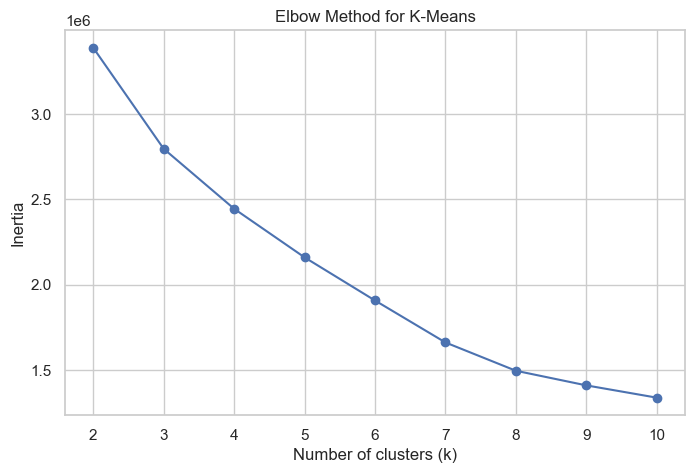

In [474]:
plt.figure(figsize=(8,5))
plt.plot(range_clusters, inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.xticks(range_clusters)
plt.show()


The optimal number of clusters is suggested by the elbow point, where adding more clusters leads to diminishing returns in inertia reduction.

To complement the elbow method, we compute the average silhouette score, which measures cluster cohesion and separation. This was performed on a representative random subsample due to computational constraints.

In [475]:
X_kmeans = X.sample(n=8000, random_state=1)


In [476]:
sil_scores = []

for k in range(2, 11):
    km = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        random_state=1
    )

    labels = km.fit_predict(X_kmeans)

    if len(np.unique(labels)) > 1:
        score = silhouette_score(X_kmeans, labels)
        sil_scores.append(score)
        print(f"k={k}, silhouette={score:.3f}")
    else:
        print(f"k={k}, only one cluster formed")

k=2, silhouette=0.371
k=3, silhouette=0.397
k=4, silhouette=0.389
k=5, silhouette=0.390
k=6, silhouette=0.311
k=7, silhouette=0.326
k=8, silhouette=0.327
k=9, silhouette=0.328
k=10, silhouette=0.329


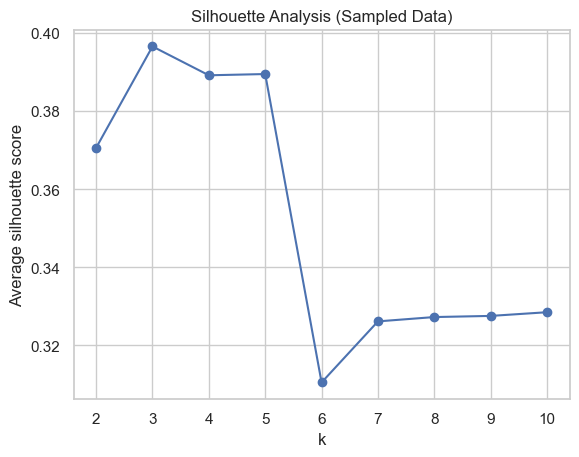

In [477]:
plt.plot(range_clusters, sil_scores, marker='o')
plt.xlabel("k")
plt.ylabel("Average silhouette score")
plt.title("Silhouette Analysis (Sampled Data)")
plt.show()


Based on the elbow and silhouette analyses, we select K = 3 clusters.

In [478]:
optimal_k = 3 

final_kmeans = KMeans(
    n_clusters=optimal_k,
    init='k-means++',
    n_init=10,
    random_state=1
)

final_df['kmeans_cluster'] = final_kmeans.fit_predict(X)


To interpret the clusters, we compute the mean profile of each cluster.

In [479]:
cluster_profile = (
    final_df
    .groupby('kmeans_cluster')[cluster_features]
    .mean()
)

cluster_profile


,NumFlights,companion_ratio,DistanceKM,RedeemRate,Income,Customer Lifetime Value,PointsAccumulated,avg_distance_per_flight
kmeans_cluster,,,,,,,,
0,0.743363,1.424731,0.744975,4.014009,-0.011396,-0.003601,0.744918,0.471333
1,-0.557439,-0.416744,-0.699010,-0.249111,0.000782,0.004858,-0.698991,-0.420018
2,0.825155,0.471062,1.066128,-0.249111,0.000581,-0.007674,1.066107,0.636634


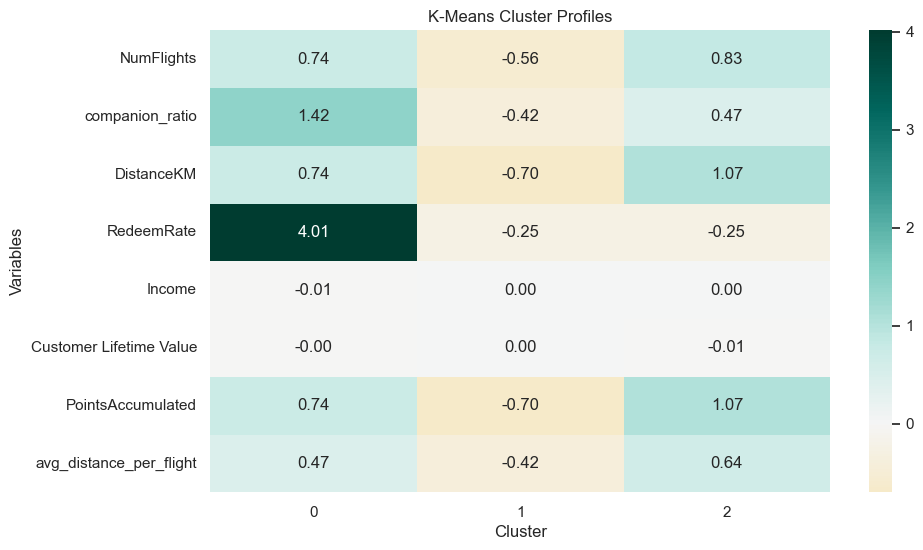

In [480]:
plt.figure(figsize=(10,6))
sns.heatmap(
    cluster_profile.T,
    annot=True,
    cmap="BrBG",
    center=0,
    fmt=".2f"
)
plt.title("K-Means Cluster Profiles")
plt.xlabel("Cluster")
plt.ylabel("Variables")
plt.show()


- **Cluster 0** represents highly engaged and loyal customers. They take more flights than average, often with companions, accumulate points and – most importantly – show a significantly high redeem rate. They are frequent users of the loyalty program and respond well to rewards.

- **Cluster 1** contains low-value and passive customers. Their flights, distance traveled, and redeem behavior are all below average. This group shows limited engagement and may require activation strategies.

- **Cluster 2** includes high-value customers characterized by long-distance flights and high points accumulation, yet low redemption behavior. They represent a strategic opportunity – customers who bring high revenue but are under-utilizing loyalty benefits, meaning targeted reward-based incentives could increase retention.

#### DBSCAN

In [481]:
final_df.head()

,NumFlights,DistanceKM,PointsAccumulated,RedeemRate,avg_distance_per_flight,companion_ratio,Gender,Income,Customer Lifetime Value,EnrollmentType,Education_College,Education_Doctor,Education_High School or Below,Education_Master,Marital Status_Married,Marital Status_Single,LoyaltyStatus_Nova,LoyaltyStatus_Star,kmeans_cluster
0,1.792346,1.658008,1.658360,-0.249111,0.052543,0.483020,-0.996809,1.065992,-0.604445,0.269005,False,False,False,False,True,False,False,True,2
1,-0.775724,-0.280943,-0.281311,-0.249111,-0.470075,-0.508304,-0.996809,1.065992,-0.604445,0.269005,False,False,False,False,True,False,False,True,1
2,-0.183092,1.586058,1.586304,-0.249111,1.727685,-0.508304,-0.996809,1.065992,-0.604445,0.269005,False,False,False,False,True,False,False,True,2
3,-0.775724,-0.776999,-0.776939,-0.249111,-0.470075,-0.508304,-0.996809,1.065992,-0.604445,0.269005,False,False,False,False,True,False,False,True,1
4,-0.775724,-0.776999,-0.776939,-0.249111,-0.470075,-0.508304,-0.996809,1.065992,-0.604445,0.269005,False,False,False,False,True,False,False,True,1


In [483]:
cluster_features = [
    'NumFlights',
    'companion_ratio',
    'DistanceKM',
    'RedeemRate',
    'Income',
    'Customer Lifetime Value',
    'PointsAccumulated',
    'avg_distance_per_flight'
]

df_cluster = final_df[cluster_features]

In [484]:
print(df_cluster.isnull().sum())

NumFlights                 0
companion_ratio            0
DistanceKM                 0
RedeemRate                 0
Income                     0
Customer Lifetime Value    0
PointsAccumulated          0
avg_distance_per_flight    0
dtype: int64


In [485]:
#  Sampling — very IMPORTANT to avoid memory crash
df_sample = df_cluster.sample(8000, random_state=1) 

In [486]:
scaler = StandardScaler()
X = scaler.fit_transform(df_sample)

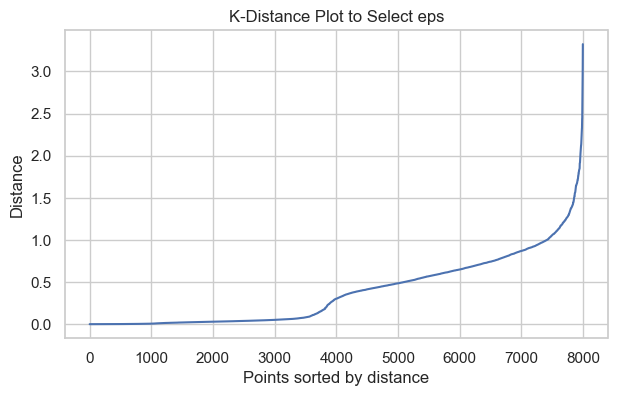

In [487]:
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)

distances = np.sort(distances[:, 4])

plt.figure(figsize=(7,4))
plt.plot(distances)
plt.title('K-Distance Plot to Select eps')
plt.xlabel('Points sorted by distance')
plt.ylabel('Distance')
plt.show()


In [488]:
db = DBSCAN(
    eps=0.5,    
    min_samples=16,   
    metric='euclidean'
).fit(X)

labels = db.labels_

df_db = df_sample.copy()
df_db["Cluster"] = labels


In [489]:
df_db = df_sample.copy()
df_db["Cluster"] = labels

In [490]:
print("Cluster Counts:\n", df_db["Cluster"].value_counts())

# Compute silhouette score (ignore noise points)
valid = df_db[df_db["Cluster"] != -1]
if valid["Cluster"].nunique() > 1:
    score = silhouette_score(valid.drop("Cluster", axis=1), valid["Cluster"])
    print("\nSilhouette Score:", score)

Cluster Counts:
 Cluster
 0    4167
-1    3674
 2      59
 1      33
 5      25
 4      23
 3      19
Name: count, dtype: int64

Silhouette Score: 0.10102146504980891


In [491]:
cluster_profile = df_db.groupby("Cluster").mean()
print("\nCluster Profile:\n")
print(cluster_profile)


Cluster Profile:

         NumFlights  companion_ratio  DistanceKM  RedeemRate    Income  \
Cluster                                                                  
-1         0.706646         0.549568    0.763628    0.288105  0.091318   
 0        -0.687594        -0.507383   -0.716194   -0.249111 -0.091106   
 1         0.323937        -0.508304   -0.402730   -0.249111  0.710188   
 2         0.680744        -0.477815    0.619500   -0.249111 -0.094151   
 3         0.619560        -0.508304    1.458695   -0.249111 -0.337218   
 4         1.474559        -0.508304    1.218454   -0.249111 -0.060489   
 5         1.196554        -0.482530   -0.034004   -0.249111 -0.284794   

         Customer Lifetime Value  PointsAccumulated  avg_distance_per_flight  
Cluster                                                                       
-1                      0.132056           0.763585                 0.497046  
 0                     -0.071224          -0.716147                -0.445235 